# TADF Experiments — Task Archetypes A–H — Results Analysis

**Data provenance:** `data/results/final/` (grid per deviation D-032: nano 2+1, mini 2+1, gpt-5.2 1+1; judge frozen gpt-5.2; temp 0, seed 42). Reproduction chain: `run_final_grid.py` → `aggregate_results.py` (master CSV) → `analyze_evidence.py` (gate statistics) → `make_figures.py` (all thesis figures).

This notebook is committed **without outputs**; run all cells to populate. Thesis figures are the committed PDFs under `docs/figures/`; the PNGs displayed here are their previews. Findings cells collect the interpretation that feeds thesis Section 4.5 and the iteration log.

*Caveat for all readings:* per-cell n is 5–25; temperature-0 run-to-run flip rate is 10.2% (49/480), so read patterns, not point estimates.

**Structure:** Section 1 gives a total overview of every run (success / failure / error / outliers). Section 2 repeats that overview per model. Section 3 then goes archetype by archetype (A–H). Section 4 closes with the TADF v1 decision tree, which an architect walks task by task when composing a larger pipeline. Section 5 revises the a-priori task dimensions against the grid evidence and derives the Phase 2b research agenda. Every code cell is preceded by a short plain-English note describing what it does.

## Requirements

*What the next cell does:* it installs matplotlib into the **current kernel** (needed for the charts). `%pip` targets the active kernel regardless of which environment is selected, so it is safe on a fresh machine. It is idempotent — if matplotlib is already present pip does nothing. Run it once; after it finishes, restart the kernel and Run All.

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Setup — load the data and define helper functions

*What the next cell does:* it loads the master results CSV (one row per run) into the list `ROWS`, converts the `success` and `total_tokens` fields to proper types, and defines the per-archetype table helpers (`cell_table`, `difficulty_table`, `robustness_table`) and the figure display helper (`fig`) that the later sections reuse. Run this first.

In [2]:
import csv, statistics, sys
from collections import defaultdict, Counter
from pathlib import Path
from IPython.display import Image, display

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
ROWS = []
with (REPO/'data/results/final/master_results.csv').open() as fh:
    for r in csv.DictReader(fh):
        r['success'] = None if r['success']=='' else (r['success']=='True')
        r['total_tokens'] = float(r['total_tokens']) if r['total_tokens'] else None
        ROWS.append(r)
MODELS = ['gpt-5.4-nano-2026-03-17','gpt-5.4-mini-2026-03-17','gpt-5.2-2025-12-11']
SHORT = {m: m.split('-2026')[0].split('-2025')[0] for m in MODELS}

def _sel(arch, kind='clean', **kw):
    out=[r for r in ROWS if r['archetype']==arch and r['kind']==kind and r['success'] is not None]
    for k,v in kw.items(): out=[r for r in out if r[k]==v]
    return out

def cell_table(arch):
    print(f'{"model":14} {"run":6} {"paradigm":9} {"success":>8} {"avg_tok":>8}')
    for m in MODELS:
        for run in ('run1','run2'):
            for p in ('workflow','agent'):
                rows=_sel(arch, model=m, run_label=run, paradigm=p)
                if not rows: continue
                s=sum(r['success'] for r in rows); t=[r['total_tokens'] for r in rows if r['total_tokens']]
                print(f'{SHORT[m]:14} {run:6} {p:9} {f"{s}/{len(rows)}":>8} {statistics.mean(t):>8.0f}')

def difficulty_table(arch):
    print(f'{"tier":6} {"paradigm":9} ' + ' '.join(f'{SHORT[m]:>12}' for m in MODELS))
    for tier in ('low','med','high'):
        for p in ('workflow','agent'):
            vals=[]
            for m in MODELS:
                rows=_sel(arch, model=m, paradigm=p, difficulty=tier)
                vals.append(f'{100*sum(r["success"] for r in rows)/len(rows):.0f}%' if rows else '-')
            print(f'{tier:6} {p:9} ' + ' '.join(f'{v:>12}' for v in vals))

def robustness_table(arch):
    for m in MODELS:
        for p in ('workflow','agent'):
            rows=_sel(arch, kind='robustness', model=m, paradigm=p)
            if rows: print(f'{SHORT[m]:14} {p:9} {sum(r["success"] for r in rows)}/{len(rows)}')

def fig(name):
    display(Image(filename=str(REPO/f'docs/figures/{name}.png'), width=760))


*What the next cell does:* it imports matplotlib and defines small helpers used by every chart below — `CLEAN` (clean runs only), `_rate` (success rate in %), `_avg_tok` (mean total tokens) and `_avg_lat` (mean latency in seconds). If matplotlib is missing in your environment, run `pip install matplotlib` once. The cell also fixes the **house style** used by every figure: blue = LLM workflow, purple = single agent, and light→dark blue for nano→mini→gpt-5.2 in per-model charts.

In [3]:
# Plotting helpers (matplotlib). If import fails in your env: pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np

# House style, reused by EVERY figure below (palette of the archetype overview charts):
# colour encodes paradigm — blue = LLM workflow, purple = single agent;
# model shades run light -> dark with capability (nano -> mini -> gpt-5.2).
C_WF = '#5b8db8'   # medium blue     -> workflow
C_AG = '#9b7fbf'   # lavender/purple -> agent
PCOL = {'workflow': C_WF, 'agent': C_AG}
MCOL = {MODELS[0]: '#b9cede', MODELS[1]: '#7da7c9', MODELS[2]: '#3f6e99'}
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

CLEAN = [r for r in ROWS if r['kind']=='clean']   # clean runs only, used for the charts

def _rate(rows):
    v=[r for r in rows if r['success'] is not None]
    return 100*sum(1 for r in v if r['success'])/len(v) if v else 0

def _avg_tok(rows):
    t=[r['total_tokens'] for r in rows if r['total_tokens']]
    return np.mean(t) if t else 0

def _avg_lat(rows):
    l=[float(r['latency_s']) for r in rows if r['latency_s'].strip()]
    return np.mean(l) if l else 0


## 1. Overall overview — all runs

Before looking at individual archetypes, this section characterises the whole dataset: how many runs there are in total, how they split into successes, plain failures, and hard errors, and where the problem cases sit.

*What the next cell does:* it defines two small helpers used throughout Sections 1 and 2. `classify(run)` labels each run as `'error'` (the run crashed, hit a validation error, or ran out of iterations), `'success'` (passed), or `'failure'` (ran fine but did not pass). `ALL` is simply every run in the dataset (clean **and** robustness runs).

In [4]:
# Helpers for the overview sections.
ALL = ROWS  # every run: clean + robustness

def classify(r):
    """Label a run as 'error', 'success', or 'failure'."""
    if (r.get('error') or '').strip():        # crash / validation error
        return 'error'
    if r.get('iteration_overflow') == 'True':  # ran out of iterations
        return 'error'
    if r['success'] is True:
        return 'success'
    return 'failure'

def _counts(rows):
    return Counter(classify(r) for r in rows)


*What the next cell does:* it prints the headline totals — the number of runs in the dataset and the share that were success / failure / error — and then breaks the same totals down two ways: by run type (`clean` vs `robustness`) and by paradigm (`workflow` vs `agent`). This answers “how many runs do we have and how many worked?”

In [5]:
n = len(ALL)
c = _counts(ALL)
print(f'TOTAL RUNS: {n}')
print(f"  success : {c['success']:4}  ({100*c['success']/n:5.1f}%)")
print(f"  failure : {c['failure']:4}  ({100*c['failure']/n:5.1f}%)")
print(f"  error   : {c['error']:4}  ({100*c['error']/n:5.1f}%)")

print('\nBy run type:')
print(f'  {"kind":11} {"n":>5} {"success":>9} {"failure":>9} {"error":>7}')
for k in ('clean','robustness'):
    sub=[r for r in ALL if r['kind']==k]; cc=_counts(sub)
    print(f'  {k:11} {len(sub):5} {cc["success"]:9} {cc["failure"]:9} {cc["error"]:7}')

print('\nBy paradigm:')
print(f'  {"paradigm":11} {"n":>5} {"success":>9} {"succ%":>7} {"failure":>9} {"error":>7}')
for p in ('workflow','agent'):
    sub=[r for r in ALL if r['paradigm']==p]; cc=_counts(sub)
    print(f'  {p:11} {len(sub):5} {cc["success"]:9} {100*cc["success"]/len(sub):6.1f}% {cc["failure"]:9} {cc["error"]:7}')


TOTAL RUNS: 1452
  success : 1109  ( 76.4%)
  failure :  335  ( 23.1%)
  error   :    8  (  0.6%)

By run type:
  kind            n   success   failure   error
  clean        1200       879       314       7
  robustness    252       230        21       1

By paradigm:
  paradigm        n   success   succ%   failure   error
  workflow      726       547   75.3%       176       3
  agent         726       562   77.4%       159       5


### Findings — headline totals

- 1,452 runs with only 8 hard errors (0.6%): the harness is sound; the 23.1% failures are model failures, not infrastructure.
- The aggregate paradigm comparison is a near-tie (workflow 75.3% vs agent 77.4%). This is the motivating non-result of the thesis: the aggregate hides opposite per-archetype gaps (D: workflow +22 pts; F: agent +25 pts), so the routing decision must be made at task level — exactly what TADF operationalizes.
- Robustness runs score higher than clean runs (91% vs 73%) because perturbations are anchored on previously solved instances — do not read this as "perturbations help".


*What the next cell does:* it shows, for each archetype A–H, how many runs it has, its overall success rate, and the success rate split by paradigm (workflow vs agent), plus the raw count of failures and hard errors. This is the “where did things not work?” table — archetypes with a low success rate or a big workflow–agent gap stand out immediately.

In [6]:
print(f'{"arch":4} {"n":>4} {"ok%":>6} {"W ok%":>7} {"A ok%":>7} {"fails":>6} {"errs":>5}')
for a in 'ABCDEFGH':
    sub=[r for r in ALL if r['archetype']==a]; cc=_counts(sub)
    def rate(p):
        ps=[r for r in sub if r['paradigm']==p]
        return 100*sum(1 for r in ps if classify(r)=='success')/len(ps) if ps else 0
    ok=100*cc['success']/len(sub)
    print(f'{a:4} {len(sub):4} {ok:5.0f}% {rate("workflow"):6.0f}% {rate("agent"):6.0f}% {cc["failure"]:6} {cc["error"]:5}')


arch    n    ok%   W ok%   A ok%  fails  errs
A     180    78%     73%     83%     38     1
B     180    75%     69%     81%     42     3
C     180    99%     98%    100%      2     0
D     186    89%    100%     78%     20     0
E     180    78%     82%     74%     39     0
F     180    66%     53%     78%     60     2
G     186    73%     68%     77%     50     1
H     180    53%     59%     47%     84     1


### Findings — per-archetype success

- Workflow-favoured: **D** (+22), **H** (+12), **E** (+8). Agent-favoured: **F** (+25), **B** (+12), **A** (+10), **G** (+9). **C** at ceiling for both. Neither direction dominates — consistent with the four-dimension taxonomy (Section 4.2.4) rather than a global winner.
- The two hardest archetypes fail for opposite reasons: **H** (53%) saturates at the high tier (both paradigms ~0%), while **F** (66%) is dragged down by the workflow being *structurally* blocked on runtime feedback (0/15 on the designed instances). Same low number, entirely different design implication.


*What the next cell does:* it lists the genuine problem cases. First every **hard error** (the 6–8 runs that crashed, failed schema validation, or hit the iteration limit), with the archetype, instance, paradigm, model and the error message. Then the **token outliers** — the runs that consumed by far the most tokens — which flag instances where a paradigm went into an expensive loop. This is the “outliers / where it broke” view.

In [7]:
errs=[r for r in ALL if classify(r)=='error']
print(f'HARD ERRORS: {len(errs)}')
for r in errs:
    msg=((r['error'] or '').strip() or 'iteration_overflow').replace('\n',' ')[:70]
    print(f"  {r['archetype']} {r['instance']:14} {r['paradigm']:9} {SHORT.get(r['model'],r['model']):9} :: {msg}")

print('\nTOKEN OUTLIERS (top 10 by total_tokens):')
tok=[r for r in ALL if r['total_tokens']]
print(f'  {"tokens":>9}  {"arch":4} {"instance":14} {"paradigm":9} {"model":9} {"outcome"}')
for r in sorted(tok, key=lambda x:-x['total_tokens'])[:10]:
    print(f"  {r['total_tokens']:9.0f}  {r['archetype']:4} {r['instance']:14} {r['paradigm']:9} {SHORT.get(r['model'],r['model']):9} {classify(r)}")

# IQR-based outlier count per (archetype, paradigm) group
print('\nOUTLIER COUNT per archetype\u00d7paradigm (tokens > Q3 + 1.5\u00d7IQR):')
groups=defaultdict(list)
for r in tok: groups[(r['archetype'],r['paradigm'])].append(r['total_tokens'])
flagged=[]
for (a,p),vals in sorted(groups.items()):
    if len(vals)<4: continue
    q=statistics.quantiles(vals, n=4); iqr=q[2]-q[0]; hi=q[2]+1.5*iqr
    k=sum(1 for v in vals if v>hi)
    if k: flagged.append(f'{a}/{p}={k}')
print('  ' + (', '.join(flagged) if flagged else 'none'))


HARD ERRORS: 8
  B b-high-4       agent     gpt-5.2   :: Recursion limit of 25 reached without hitting a stop condition. You ca
  H h-high-3       agent     gpt-5.2   :: iteration_overflow
  A a-med-1        workflow  gpt-5.4-mini :: 1 validation error for SearchPlan   Invalid JSON: trailing characters 
  B b-high-4       agent     gpt-5.4-mini :: Recursion limit of 25 reached without hitting a stop condition. You ca
  B b-high-4       agent     gpt-5.4-mini :: Recursion limit of 25 reached without hitting a stop condition. You ca
  G g-low-5        agent     gpt-5.4-mini :: iteration_overflow
  F rf-med-2       workflow  gpt-5.4-nano :: 153 validation errors for ActionPlan actions.0.args.updates.str   Inpu
  F f-high-4       workflow  gpt-5.4-nano :: 18 validation errors for ActionPlan actions.0.args.filters.str   Input

TOKEN OUTLIERS (top 10 by total_tokens):
     tokens  arch instance       paradigm  model     outcome
     141548  F    f-med-5        agent     gpt-5.4-nano failure


### Findings — errors and outliers

- Structural fragility is **symmetric but paradigm-typed** (evidence item 13): workflow crashes are schema-validation failures on plan objects (`SearchPlan`, `ActionPlan` — the structured-output ceiling made visible), agent crashes are recursion/iteration overflows (unbounded loops). Each paradigm therefore needs its own guardrail: schema-complexity budget for workflows, iteration caps for agents.
- Token outliers sit almost exclusively in **agent** cells of B, F and G — the loop archetypes, where failed attempts re-enter the context. The workflow outliers in F are validation-retry inflation on nano.
- `b-high-4` overflows the agent on 3 of 3 attempts across two models — an instance-level property, not a model-level one.
- *Open:* trace walkthroughs for `b-high-4` and `g-low-5` (why does a *low* instance overflow?); check whether the F workflow outliers disappear above nano.


## 2. Per-model overview

The same success / failure / error picture, but now separated by model. Note the models do **not** have equal run counts (nano and mini were run twice plus robustness; gpt-5.2 once plus robustness), so compare rates, not raw counts.

*What the next cell does:* for each model it prints the total run count, the overall success / failure / error split, and then — within that model — the success rate and average token cost for workflow vs agent. This shows how each model behaves and how the workflow–agent gap changes as model capability increases (nano → mini → gpt-5.2).

In [8]:
for m in MODELS:
    sub=[r for r in ALL if r['model']==m]; cc=_counts(sub); n=len(sub)
    print(f'{SHORT[m]}  (n={n})')
    print(f"  success {cc['success']:4}/{n} ({100*cc['success']/n:5.1f}%)   failure {cc['failure']:4}   error {cc['error']}")
    for p in ('workflow','agent'):
        ps=[r for r in sub if r['paradigm']==p]; pc=_counts(ps)
        pt=[r['total_tokens'] for r in ps if r['total_tokens']]
        avg=statistics.mean(pt) if pt else 0
        print(f"    {p:9} success {pc['success']:4}/{len(ps):4} ({100*pc['success']/len(ps):5.0f}%)   avg_tok {avg:8.0f}   errors {pc['error']}")
    print()


gpt-5.4-nano  (n=564)
  success  405/564 ( 71.8%)   failure  157   error 2
    workflow  success  199/ 282 (   71%)   avg_tok     2759   errors 2
    agent     success  206/ 282 (   73%)   avg_tok     9703   errors 0

gpt-5.4-mini  (n=564)
  success  435/564 ( 77.1%)   failure  125   error 4
    workflow  success  219/ 282 (   78%)   avg_tok     2348   errors 1
    agent     success  216/ 282 (   77%)   avg_tok     6153   errors 3

gpt-5.2  (n=324)
  success  269/324 ( 83.0%)   failure   53   error 2
    workflow  success  129/ 162 (   80%)   avg_tok     2587   errors 0
    agent     success  140/ 162 (   86%)   avg_tok     6650   errors 2



### Findings — per-model table

- Success rises monotonically with capability (71.8% → 77.1% → 83.0%), but the workflow–agent gap does **not** close monotonically (nano +2, mini −1, gpt-5.2 +6 pts for the agent) — capability does not simply substitute for architecture.
- Workflow token cost is roughly capability-invariant (2.3–2.8k): the structure, not the model, sets the budget. Agent cost drops sharply nano → mini (9.7k → 6.2k; fewer wasted loop iterations) and then plateaus.
- Read all per-model numbers against the 10.2% temperature-0 flip rate, and note gpt-5.2 has half the run count.


*What the next cell does:* it draws a 2\u00d72 dashboard comparing the three models on the clean runs, with workflow vs agent bars side by side in each panel: (top-left) success rate, (top-right) average total tokens, (bottom-left) average latency in seconds, and (bottom-right) number of hard errors. This is the visual version of the per-model table above — it shows the success/cost/latency/error trade-off per model at a glance.

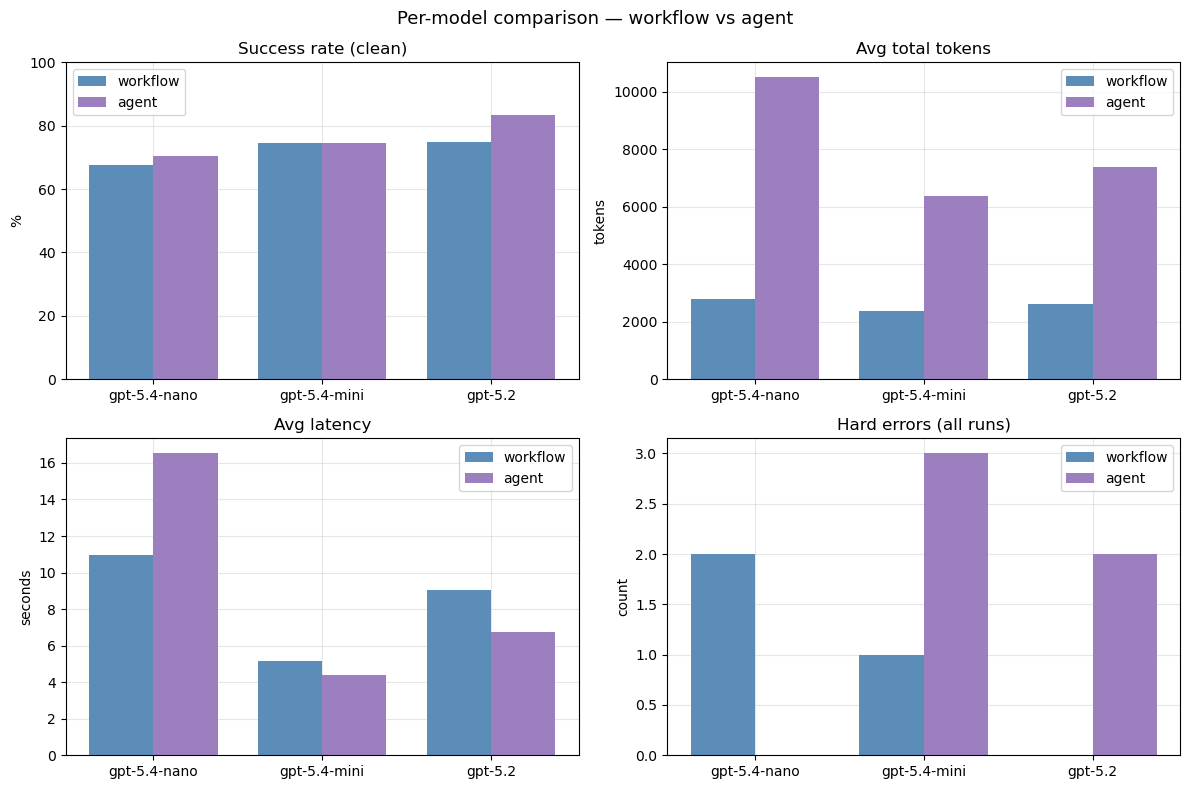

In [9]:
x=np.arange(len(MODELS)); w=0.38; labels=[SHORT[m] for m in MODELS]
f,ax=plt.subplots(2,2,figsize=(12,8))

for i,p in enumerate(('workflow','agent')):
    off=(i-0.5)*w; col=PCOL[p]
    ax[0,0].bar(x+off,[_rate([r for r in CLEAN if r['model']==m and r['paradigm']==p]) for m in MODELS],w,label=p,color=col)
    ax[0,1].bar(x+off,[_avg_tok([r for r in CLEAN if r['model']==m and r['paradigm']==p]) for m in MODELS],w,label=p,color=col)
    ax[1,0].bar(x+off,[_avg_lat([r for r in CLEAN if r['model']==m and r['paradigm']==p]) for m in MODELS],w,label=p,color=col)
    ax[1,1].bar(x+off,[sum(1 for r in ALL if r['model']==m and r['paradigm']==p and classify(r)=='error') for m in MODELS],w,label=p,color=col)

ax[0,0].set_title('Success rate (clean)');  ax[0,0].set_ylabel('%'); ax[0,0].set_ylim(0,100)
ax[0,1].set_title('Avg total tokens');       ax[0,1].set_ylabel('tokens')
ax[1,0].set_title('Avg latency');            ax[1,0].set_ylabel('seconds')
ax[1,1].set_title('Hard errors (all runs)'); ax[1,1].set_ylabel('count')
for a in ax.flat:
    a.set_xticks(x); a.set_xticklabels(labels); a.legend(); a.grid(axis='y', alpha=0.3)
f.suptitle('Per-model comparison — workflow vs agent', fontsize=13)
plt.tight_layout(); plt.show()


### Findings — model dashboard

- On every model the agent buys its extra success at **2.6–3.5× tokens** and higher latency; the trade-off never disappears, it only gets cheaper with capability.
- Hard errors are paradigm-specific rather than model-specific (validation crashes vs loop overflows) — consistent with the outlier analysis above.
- nano functions as the stress test of the grid: it exposes failure modes (permissive compliance in D, argument-binding failures in G, validation crashes in F) that mini/gpt-5.2 partially mask. Useful for *design* evidence, not for headline numbers.


## 3. Per-archetype analysis

From here the notebook goes archetype by archetype (A–H). For each one the code cell prints three tables and shows two figures; the following *Findings* cell records the interpretation.

*What the next cell does:* it lays out **every collected KPI** on one grid (like a benchmark scorecard), all models pooled on the clean runs. Each panel is one KPI with archetypes A\u2013H on the x-axis and one line per paradigm (blue = workflow, purple = agent). The band between the two lines is lightly shaded toward the **better** paradigm — higher is better for success rate, lower is better for the cost KPIs (tokens, tool calls, latency). This is the single-glance overview of who wins where, on what.

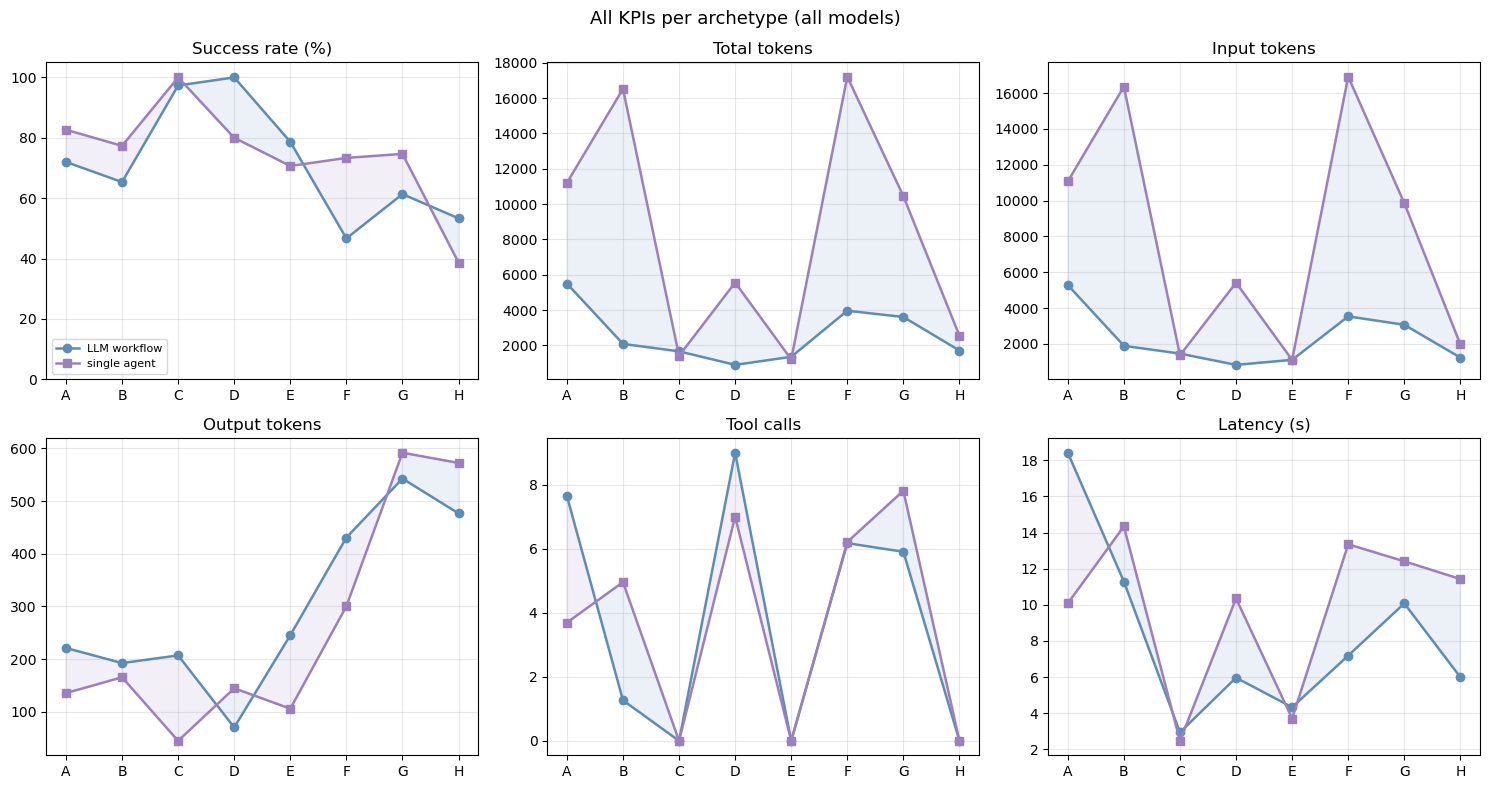

In [10]:
arches=list('ABCDEFGH'); xs=np.arange(len(arches))
C_WF='#5b8db8'; C_AG='#9b7fbf'

# (title, field, higher_is_better)
KPIS=[('Success rate (%)','success',True),
      ('Total tokens','total_tokens',False),
      ('Input tokens','input_tokens',False),
      ('Output tokens','output_tokens',False),
      ('Tool calls','tool_call_count',False),
      ('Latency (s)','latency_s',False)]

def _kpi(rows, field):
    if field=='success': return _rate(rows)
    vals=[]
    for r in rows:
        x=r.get(field)
        if isinstance(x,float): vals.append(x)
        elif x not in (None,'') and str(x).strip():
            try: vals.append(float(x))
            except ValueError: pass
    return np.mean(vals) if vals else 0

f,axes=plt.subplots(2,3,figsize=(15,8))
for ax,(title,field,hib) in zip(axes.flat,KPIS):
    w=np.array([_kpi([r for r in CLEAN if r['archetype']==a and r['paradigm']=='workflow'],field) for a in arches])
    g=np.array([_kpi([r for r in CLEAN if r['archetype']==a and r['paradigm']=='agent'],field) for a in arches])
    if hib:
        ax.fill_between(xs,w,g,where=w>=g,interpolate=True,color=C_WF,alpha=0.12,zorder=0)
        ax.fill_between(xs,w,g,where=g>w,interpolate=True,color=C_AG,alpha=0.12,zorder=0)
    else:
        ax.fill_between(xs,w,g,where=w<=g,interpolate=True,color=C_WF,alpha=0.12,zorder=0)
        ax.fill_between(xs,w,g,where=g<w,interpolate=True,color=C_AG,alpha=0.12,zorder=0)
    ax.plot(xs,w,'-o',color=C_WF,linewidth=1.8,zorder=3,label='LLM workflow')
    ax.plot(xs,g,'-s',color=C_AG,linewidth=1.8,zorder=3,label='single agent')
    ax.set_title(title); ax.set_xticks(xs); ax.set_xticklabels(arches); ax.grid(alpha=0.3)
axes.flat[0].set_ylim(0,105); axes.flat[0].legend(fontsize=8,loc='lower left')
f.suptitle('All KPIs per archetype (all models)',fontsize=13)
plt.tight_layout(); plt.show()


### Findings — KPI grid

- Success panel: the agent wins the **adaptivity** archetypes (A, B, F, G), the workflow wins the **structure** archetypes (D, E, H), C ties at ceiling — the visual core of the routing thesis.
- Cost panels: the workflow is cheaper everywhere except **C** (inverted — fixed chunking is pure overhead in a single-step task, IT-044) and **E** (parity, both tool-free).
- Note archetype A: the workflow makes ~2.5× *more tool calls* (upfront query fan-out into the 10-query cap, IT-042) yet spends *fewer tokens* — the cost drivers differ per paradigm (planned queries vs context re-entry per loop).


*What the next cell does:* whole-picture view of the eight archetypes, all models pooled (clean runs). Left axis, **solid** lines = success rate (workflow vs agent); right axis (log), **dashed** lines = average token cost. Colour encodes paradigm (blue = workflow, purple = agent). The gap between each pair of lines is lightly shaded toward the **better** paradigm — for success that means the higher line, for tokens the cheaper (lower) line — so you can see at a glance who wins on quality and who wins on cost per archetype.

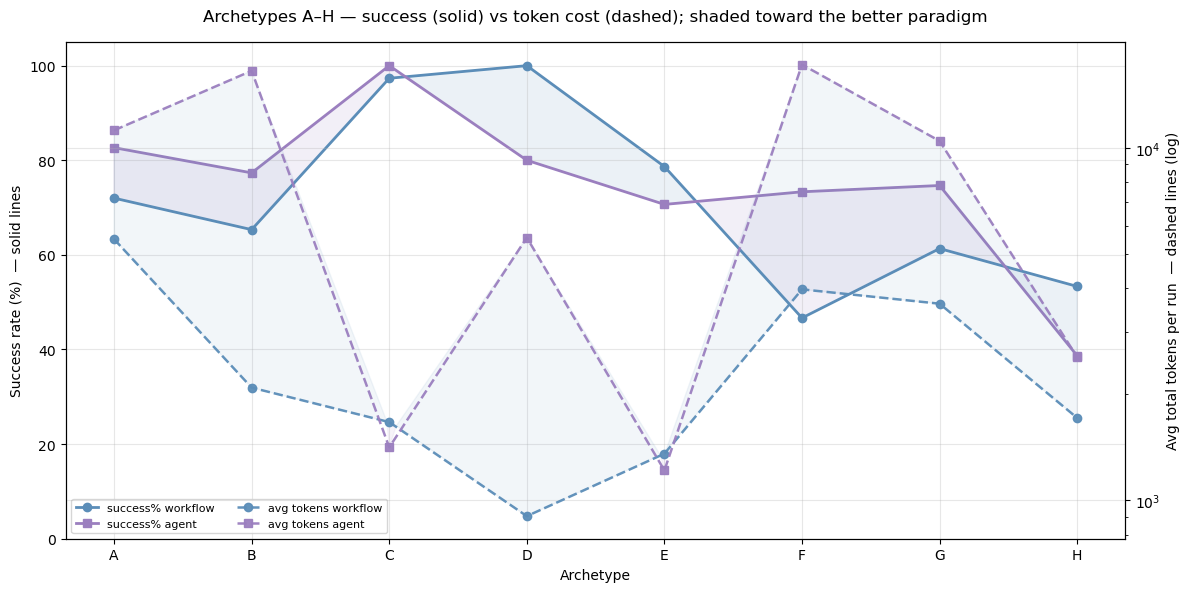

In [11]:
arches=list('ABCDEFGH')
xs=np.arange(len(arches))

# Palette: color encodes paradigm, line style encodes metric
# (solid = success rate, dashed = token cost).
C_WF = '#5b8db8'   # medium blue    -> workflow
C_AG = '#9b7fbf'   # lavender/purple -> agent

# collect series for both paradigms
succ={p:np.array([_rate([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}
toks={p:np.array([_avg_tok([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}

f,ax1=plt.subplots(figsize=(12,6))
ax2=ax1.twinx()

# --- shaded gaps ---
# success: 'better' = higher -> tint toward the winning paradigm
ax1.fill_between(xs,succ['workflow'],succ['agent'],where=succ['workflow']>=succ['agent'],
                 interpolate=True,color=C_WF,alpha=0.12,zorder=0)
ax1.fill_between(xs,succ['workflow'],succ['agent'],where=succ['agent']>succ['workflow'],
                 interpolate=True,color=C_AG,alpha=0.12,zorder=0)
# tokens: 'better' = cheaper (fewer tokens) -> tint toward the cheaper paradigm
ax2.fill_between(xs,toks['workflow'],toks['agent'],where=toks['workflow']<=toks['agent'],
                 interpolate=True,color=C_WF,alpha=0.08,zorder=0)
ax2.fill_between(xs,toks['workflow'],toks['agent'],where=toks['agent']<toks['workflow'],
                 interpolate=True,color=C_AG,alpha=0.08,zorder=0)

# --- lines on top ---
for p,color,marker in (('workflow',C_WF,'o'),('agent',C_AG,'s')):
    ax1.plot(xs,succ[p],'-',marker=marker,linewidth=2,color=color,zorder=3,label=f'success% {p}')
    ax2.plot(xs,toks[p],'--',marker=marker,linewidth=1.8,color=color,alpha=0.95,zorder=3,label=f'avg tokens {p}')

ax1.set_ylabel('Success rate (%)  — solid lines'); ax1.set_ylim(0,105)
ax1.set_xticks(xs); ax1.set_xticklabels(arches)
ax1.set_xlabel('Archetype'); ax1.grid(axis='y',alpha=0.3)
ax2.set_yscale('log'); ax2.set_ylabel('Avg total tokens per run  — dashed lines (log)')

h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2,loc='lower left',fontsize=8,ncol=2)

f.suptitle('Archetypes A\u2013H — success (solid) vs token cost (dashed); shaded toward the better paradigm',fontsize=12)
plt.tight_layout(); plt.show()


### Findings — success vs token cost

- The token gap (log axis) is archetype-dependent: ~1× (C, E) to 5–15× (B, D, F). The agent premium is *justified* exactly where its success line is also on top (A, F, G) and *wasted* where it is not (D, H).
- B is the cleanest "pay more, buy the med tier" case: 3.3× tokens buys +28 pts at med — while at high both paradigms collapse (32%/40%), so additional spend does not buy the saturated cells. Saturation is a budget argument, not only a quality argument.


*What the next cell does:* same combined view as the success/token chart, but the right axis is now **latency**. Left axis, **solid** lines = success rate (higher better); right axis, **dashed** lines = average latency in seconds (lower better). Bands shade toward the better paradigm for each metric. Shows the quality-vs-speed trade-off per archetype.

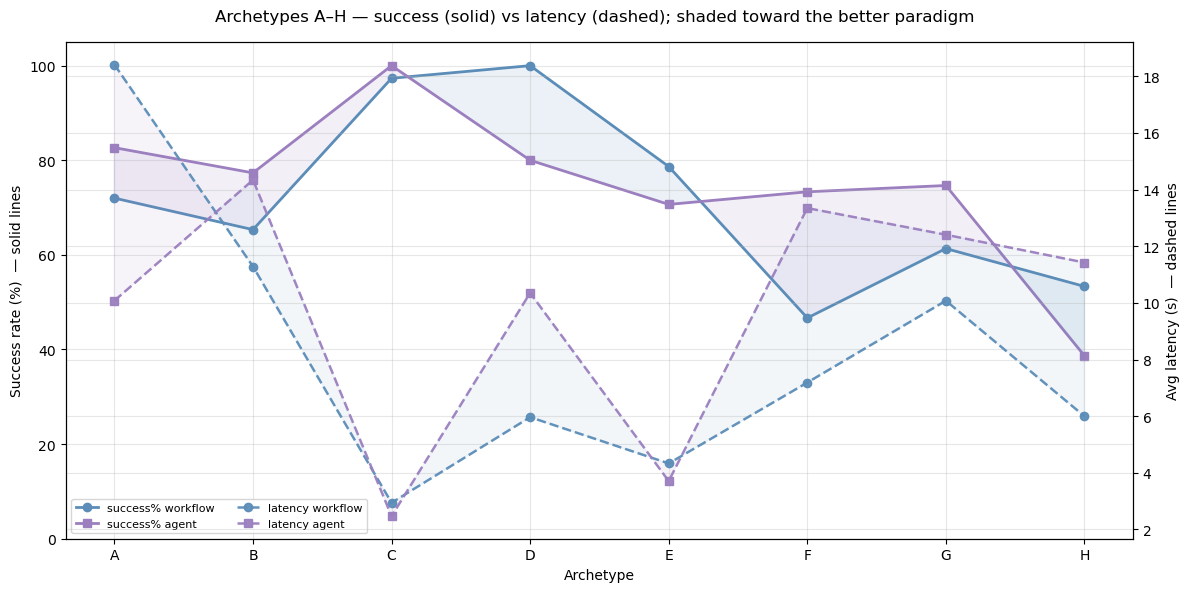

In [12]:
arches=list('ABCDEFGH'); xs=np.arange(len(arches)); C_WF='#5b8db8'; C_AG='#9b7fbf'
succ={p:np.array([_rate([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}
lat ={p:np.array([_avg_lat([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}

f,ax1=plt.subplots(figsize=(12,6)); ax2=ax1.twinx()
# success shading (higher better)
ax1.fill_between(xs,succ['workflow'],succ['agent'],where=succ['workflow']>=succ['agent'],interpolate=True,color=C_WF,alpha=0.12,zorder=0)
ax1.fill_between(xs,succ['workflow'],succ['agent'],where=succ['agent']>succ['workflow'],interpolate=True,color=C_AG,alpha=0.12,zorder=0)
# latency shading (lower better)
ax2.fill_between(xs,lat['workflow'],lat['agent'],where=lat['workflow']<=lat['agent'],interpolate=True,color=C_WF,alpha=0.08,zorder=0)
ax2.fill_between(xs,lat['workflow'],lat['agent'],where=lat['agent']<lat['workflow'],interpolate=True,color=C_AG,alpha=0.08,zorder=0)
for p,color,marker in (('workflow',C_WF,'o'),('agent',C_AG,'s')):
    ax1.plot(xs,succ[p],'-',marker=marker,linewidth=2,color=color,zorder=3,label=f'success% {p}')
    ax2.plot(xs,lat[p],'--',marker=marker,linewidth=1.8,color=color,alpha=0.95,zorder=3,label=f'latency {p}')
ax1.set_ylabel('Success rate (%)  — solid lines'); ax1.set_ylim(0,105)
ax1.set_xticks(xs); ax1.set_xticklabels(arches); ax1.set_xlabel('Archetype'); ax1.grid(axis='y',alpha=0.3)
ax2.set_ylabel('Avg latency (s)  — dashed lines')
h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2,loc='lower left',fontsize=8,ncol=2)
f.suptitle('Archetypes A\u2013H — success (solid) vs latency (dashed); shaded toward the better paradigm',fontsize=12)
plt.tight_layout(); plt.show()


### Findings — success vs latency

- Latency follows the same paradigm split as tokens: where the agent loops (B, F, G) it is also the slower paradigm, so interactive deployments pay a **triple premium** (tokens, latency, error surface) for agent loops — relevant for the APS weighting in Phase 3.
- Exception worth flagging: in A the workflow is token-cheap but latency-expensive at the low tier (5-query fan-out under synthetic per-call latency, IT-038/D-022) — upfront over-planning has a visible time cost even when it is cheap.


*What the next cell does:* both **cost** KPIs together, no success here. Left axis (log), **solid** lines = average total tokens; right axis, **dashed** lines = average latency. Colour = paradigm; for each metric the band is shaded toward the **cheaper** (lower) paradigm. Shows where a paradigm is cheap on tokens but slow, or vice versa.

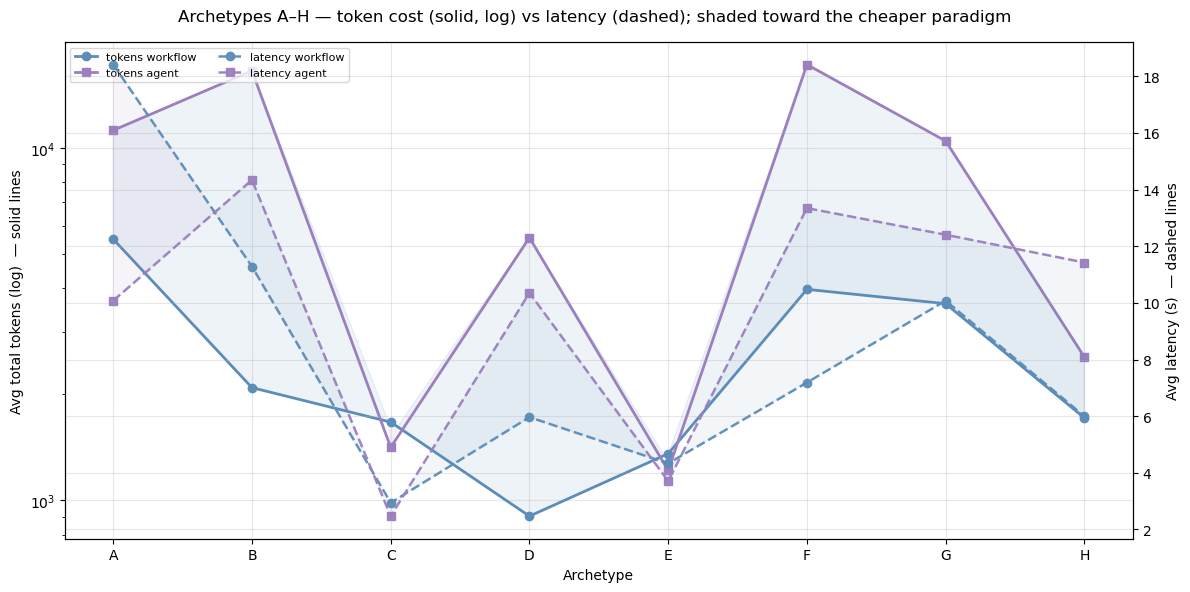

In [13]:
arches=list('ABCDEFGH'); xs=np.arange(len(arches)); C_WF='#5b8db8'; C_AG='#9b7fbf'
toks={p:np.array([_avg_tok([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}
lat ={p:np.array([_avg_lat([r for r in CLEAN if r['archetype']==a and r['paradigm']==p]) for a in arches]) for p in ('workflow','agent')}

f,ax1=plt.subplots(figsize=(12,6)); ax2=ax1.twinx()
# tokens shading (lower better) — on log axis
ax1.fill_between(xs,toks['workflow'],toks['agent'],where=toks['workflow']<=toks['agent'],interpolate=True,color=C_WF,alpha=0.10,zorder=0)
ax1.fill_between(xs,toks['workflow'],toks['agent'],where=toks['agent']<toks['workflow'],interpolate=True,color=C_AG,alpha=0.10,zorder=0)
# latency shading (lower better)
ax2.fill_between(xs,lat['workflow'],lat['agent'],where=lat['workflow']<=lat['agent'],interpolate=True,color=C_WF,alpha=0.08,zorder=0)
ax2.fill_between(xs,lat['workflow'],lat['agent'],where=lat['agent']<lat['workflow'],interpolate=True,color=C_AG,alpha=0.08,zorder=0)
for p,color,marker in (('workflow',C_WF,'o'),('agent',C_AG,'s')):
    ax1.plot(xs,toks[p],'-',marker=marker,linewidth=2,color=color,zorder=3,label=f'tokens {p}')
    ax2.plot(xs,lat[p],'--',marker=marker,linewidth=1.8,color=color,alpha=0.95,zorder=3,label=f'latency {p}')
ax1.set_yscale('log'); ax1.set_ylabel('Avg total tokens (log)  — solid lines')
ax1.set_xticks(xs); ax1.set_xticklabels(arches); ax1.set_xlabel('Archetype'); ax1.grid(axis='y',alpha=0.3)
ax2.set_ylabel('Avg latency (s)  — dashed lines')
h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2,loc='upper left',fontsize=8,ncol=2)
f.suptitle('Archetypes A\u2013H — token cost (solid, log) vs latency (dashed); shaded toward the cheaper paradigm',fontsize=12)
plt.tight_layout(); plt.show()


### Findings — token cost vs latency

- Tokens and latency are correlated but **not interchangeable**: A's workflow is cheap on tokens yet slow (query fan-out); C and E are cheap *and* fast for both paradigms (no tools). If APS weights cost and latency differently, the two axes can rank the paradigms differently for the same archetype.
- *Open:* latency here mixes real LLM latency with the synthetic 300 ms ± 50 ms per tool call (D-022); a sensitivity note in 4.5 should state how conclusions change if real API latencies dominate.


*What the next cell does:* it plots average latency (x) against success rate (y) with one point per archetype\u00d7model, coloured by model (clean runs). Each point is labelled with its archetype letter. It shows whether slower runs tend to succeed more, and how the three models sit relative to each other on the speed/quality trade-off.

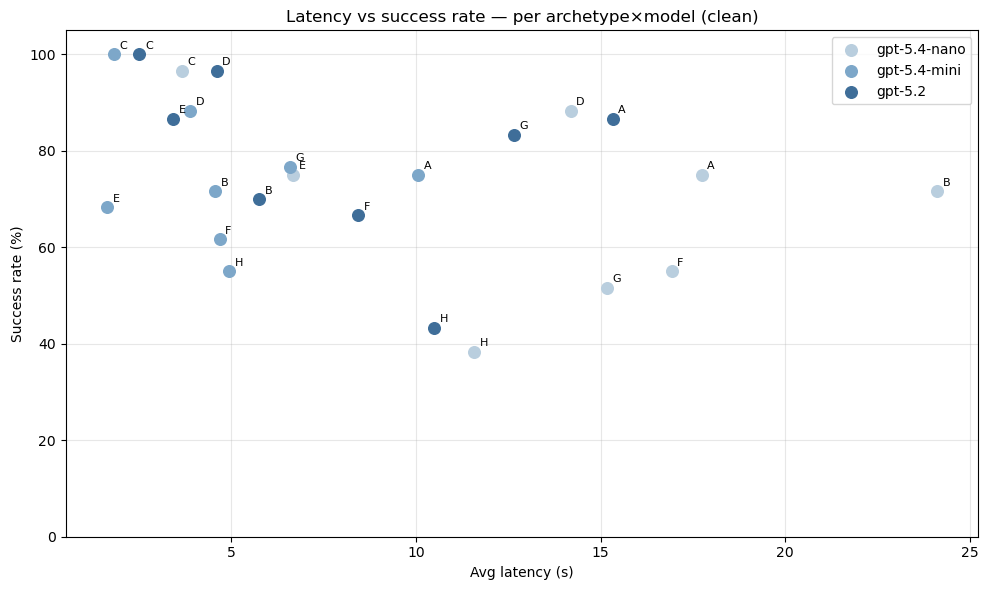

In [14]:
arches=list('ABCDEFGH')
f,ax=plt.subplots(figsize=(10,6))
for m in MODELS:
    xs=[];ys=[];lab=[]
    for a in arches:
        rows=[r for r in CLEAN if r['model']==m and r['archetype']==a]
        if not rows: continue
        xs.append(_avg_lat(rows)); ys.append(_rate(rows)); lab.append(a)
    ax.scatter(xs,ys,s=70,color=MCOL[m],label=SHORT[m])
    for xi,yi,a in zip(xs,ys,lab):
        ax.annotate(a,(xi,yi),textcoords='offset points',xytext=(4,4),fontsize=8)
ax.set_xlabel('Avg latency (s)'); ax.set_ylabel('Success rate (%)'); ax.set_ylim(0,105)
ax.set_title('Latency vs success rate — per archetype\u00d7model (clean)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Findings — latency vs success scatter

- There is no global "slower = better" frontier: points cluster by **archetype**, not along a speed–quality trade-off. H and B sit low for every model regardless of time spent — saturation again.
- Capability moves clusters *up* (success) more than *left* (speed): model choice buys quality, architecture choice buys cost and latency. The two decisions are separable, which is what makes a task-level routing framework feasible at all.


## Archetype A — Exploratory Research and Synthesis

Rule reference: iteration-log TADF v1 rule block for A; figures `fig_diff_a.pdf` and `fig_a_exploratory_research.pdf`.

*What the next cell does:* it prints three tables for archetype A — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow      9/15     6299
gpt-5.4-nano   run1   agent        12/15    12248
gpt-5.4-nano   run2   workflow     11/15     6571
gpt-5.4-nano   run2   agent        13/15    13594
gpt-5.4-mini   run1   workflow     12/15     4601
gpt-5.4-mini   run1   agent        11/15     7208
gpt-5.4-mini   run2   workflow     10/15     4073
gpt-5.4-mini   run2   agent        12/15    11933
gpt-5.2        run1   workflow     12/15     5931
gpt-5.2        run1   agent        14/15    11042

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow           90%          80%          80%
low    agent              90%          50%         100%
med    workflow           80%          70%          80%
med    agent              70%          90%          80%
high   workflow           30%          70%          80%
high   agent              90%          90%         100%

gpt-5.4-nano   workflow  4/5
gpt-5.4-nano   agent     4/

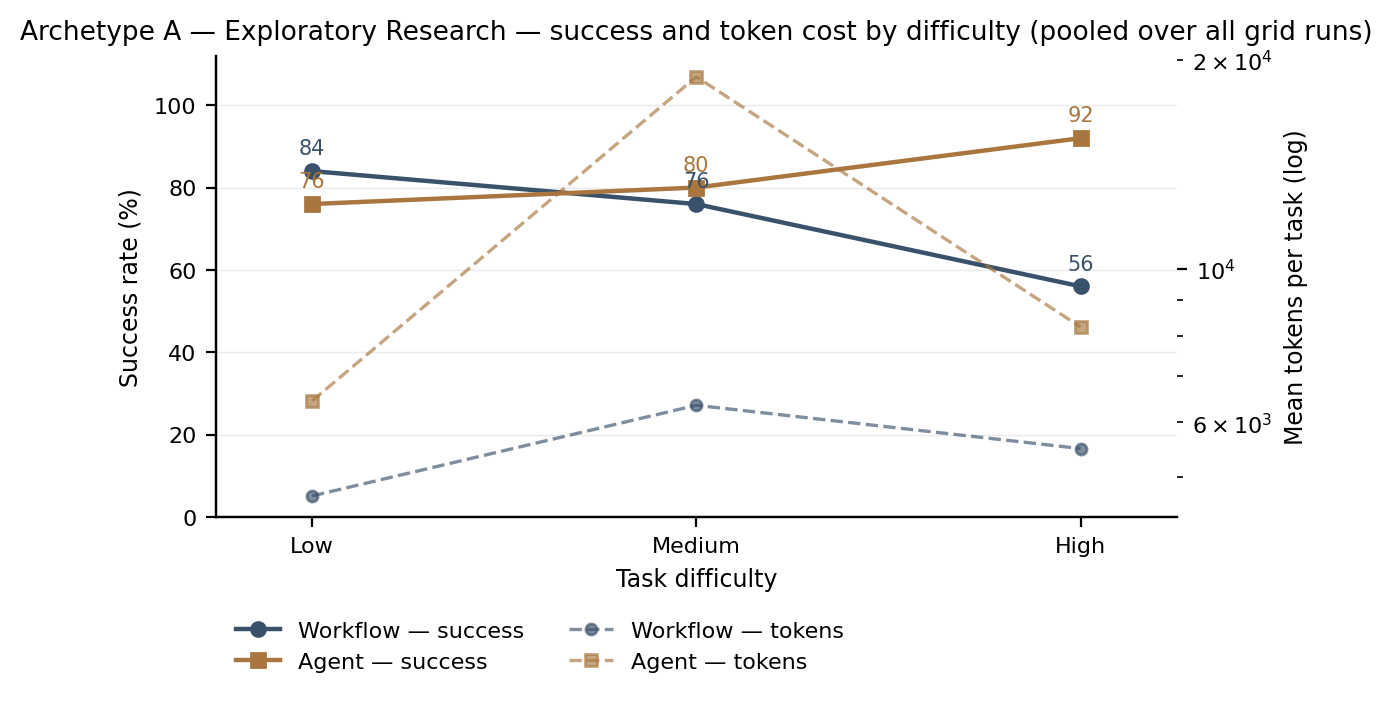

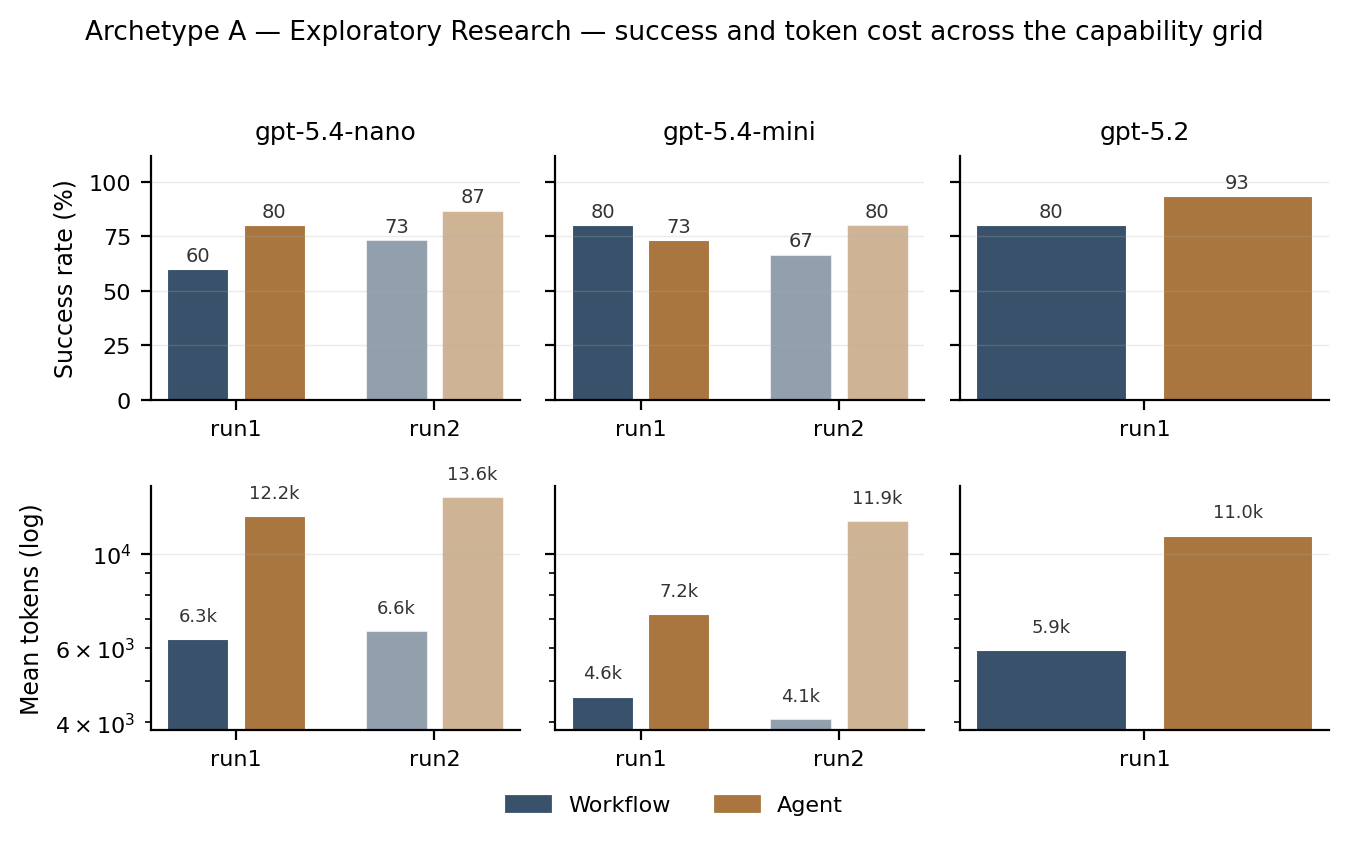

In [15]:
cell_table('A')
print()
difficulty_table('A')
print()
robustness_table('A')
fig('fig_diff_a')
fig('fig_a_exploratory_research')

### Findings A — Exploratory Research and Synthesis

**Results.** The workflow leads the low tier (84% vs 76%) and is cheaper there (4.7k vs 6.4k tokens); the ranking crosses at med (76% vs 80%) and inverts decisively at high (56% vs 92%). The gap narrows with capability (60 → 20 pts, gpt-5.2 high: 4/5 vs 5/5) but never flips sign. Robustness: W 12/15 vs A 13/15.

**Interpretation (task and paradigm construction).** The workflow plans *all* queries before seeing a single result (`plan_searches → execute → synthesize`). Low-tier lookups are plan-time decidable, so the fixed form suffices and is cheaper. High-tier instances are *chained*: the query for hop *n* depends on the answer of hop *n−1* (IT-042), which the two-stage form structurally cannot express — the workflow over-plans into the 10-query cap (~8 tool calls vs agent ~3) and still misses the chain. This is why the workflow degrades with difficulty while the agent improves.

**Token anomaly (med > high).** Agent tokens peak at *med* (~18.9k) and drop at *high* (~8.2k) on every model. Two design-based reasons: (i) med difficulty is operationalized as *breadth* — number of sources to combine (IT-032/IT-039) — so more payloads re-enter the context, while high is *depth* — single-value chained hops (IT-042) with few, targeted searches; (ii) residual memorization on famous entities lets stronger models shortcut individual instances (3/15 flagged on gpt-5.2, IT-051), skipping retrieval and its token cost entirely.

**Open points.** Re-run the no-tool memorization check per model before quoting the high-tier 92% (IT-039 method note: the strongest model sets the bar); walkthrough of the nano `SearchPlan` validation crash (a-med-1) — structured-output fragility exists on the workflow side too.

**TADF implication.** Open, chained search → agent (gate G3). At the low tier with low error consequence the workflow remains viable and cheaper (IT-012 refinement) — the rule is tier-conditional, not archetype-global.


## Archetype B — Structured Data Retrieval and Transformation

Rule reference: iteration-log TADF v1 rule block for B; figures `fig_diff_b.pdf` and `fig_b_structured_retrieval.pdf`.

*What the next cell does:* it prints three tables for archetype B — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow     11/15     2112
gpt-5.4-nano   run1   agent        11/15    18777
gpt-5.4-nano   run2   workflow      9/15     2107
gpt-5.4-nano   run2   agent        12/15    22347
gpt-5.4-mini   run1   workflow     11/15     2048
gpt-5.4-mini   run1   agent        11/15     9857
gpt-5.4-mini   run2   workflow     10/15     2045
gpt-5.4-mini   run2   agent        11/15    11338
gpt-5.2        run1   workflow      8/15     2132
gpt-5.2        run1   agent        13/15    19736

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow          100%         100%         100%
low    agent             100%         100%         100%
med    workflow           70%          60%          60%
med    agent              80%         100%         100%
high   workflow           30%          50%           0%
high   agent              50%          20%          60%

gpt-5.4-nano   workflow  4/5
gpt-5.4-nano   agent     5/

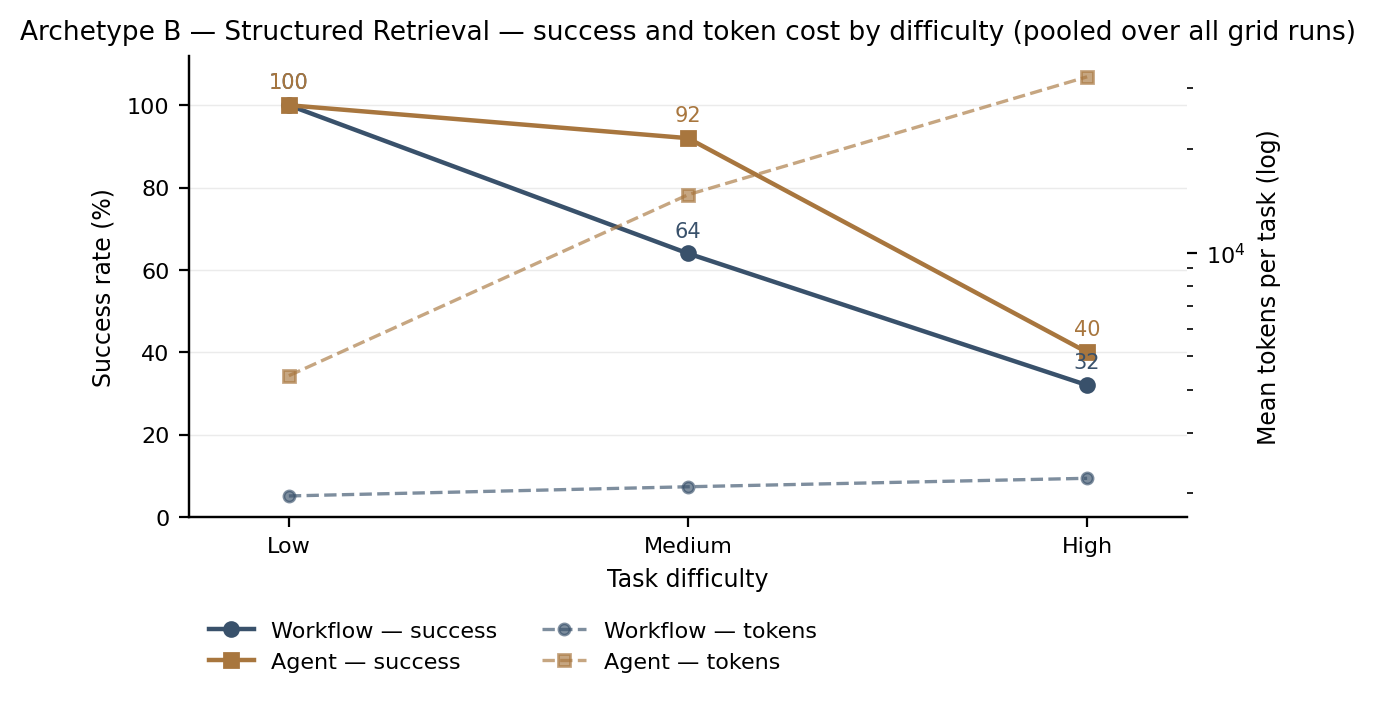

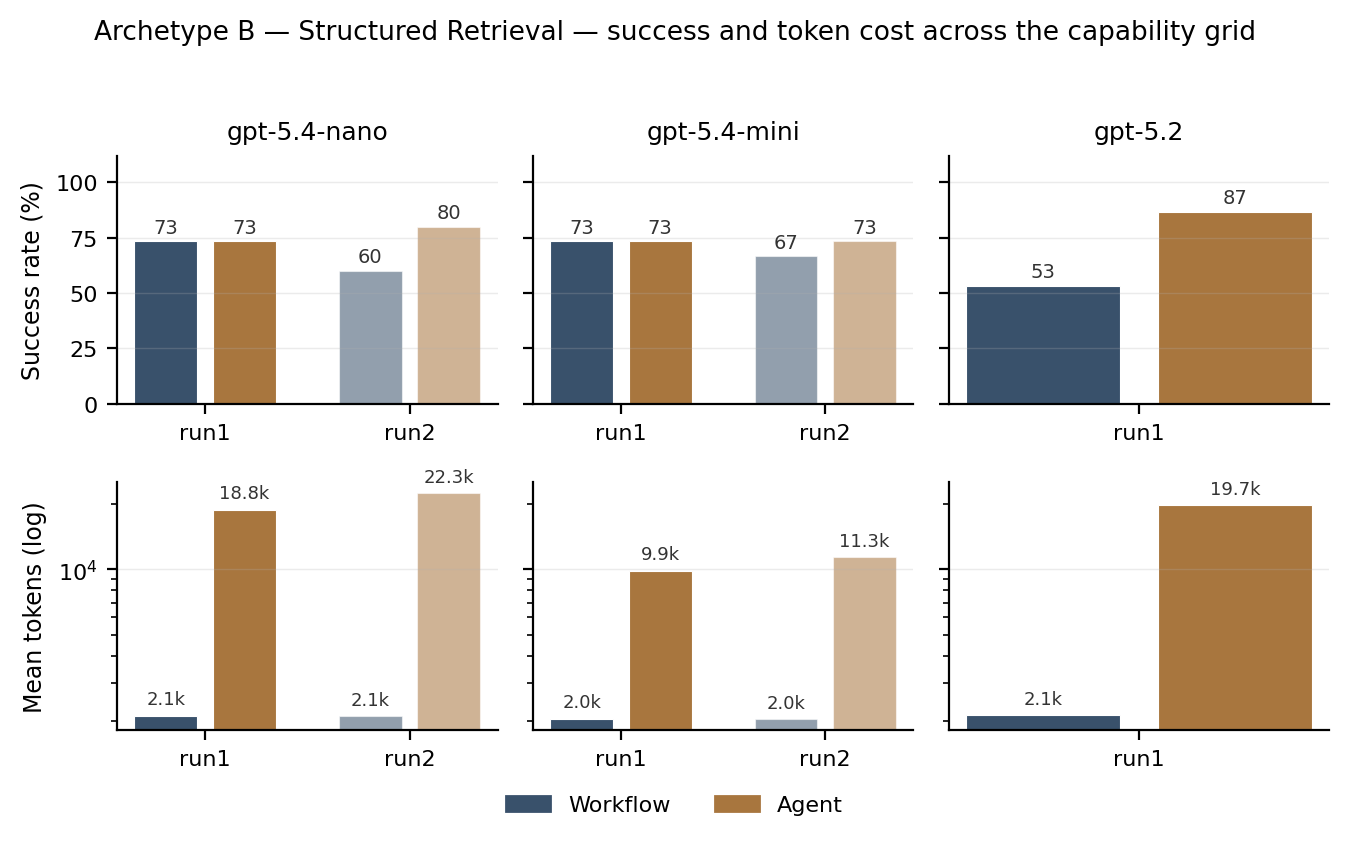

In [16]:
cell_table('B')
print()
difficulty_table('B')
print()
robustness_table('B')
fig('fig_diff_b')
fig('fig_b_structured_retrieval')

### Findings B — Structured Data Retrieval and Transformation

**Results.** Parity at low (100% both) with the workflow 2.2× cheaper; at med/high the workflow drops to 64%/32% while the agent holds 92%/40%. Workflow token cost is *flat across tiers* (~2.0–2.2k) while agent cost explodes 4.4k → 14.7k → 32.4k. B/agent has the most token outliers in the grid (15) and all three recursion-limit crashes (`b-high-4`). Robustness inverts the clean ranking: W 13/15 vs A 15/15 (IT-036: the agent is more robust to messy input).

**Interpretation.** The workflow's cost is fixed *by construction*: one plan call + deterministic executor + one format call — difficulty changes the SQL, not the token bill (IT-043 tool-router form). The agent pays per observation: raw multi-source payloads re-enter the context on every loop iteration, so cost scales with join depth and with every failed attempt. The med-tier gap (64% vs 92%) shows the planner, not the executor, is the workflow's weak point once several sources must be combined.

**Saturation.** The high tier (3+ fields combined across systems into one compound answer) is unstable for *both* (8/25 vs 10/25) — a saturation cell (evidence item 6). Neither paradigm carries it; the evidenced recommendation is task **decomposition**, not paradigm choice.

**Open points.** Walkthrough of the two workflow robustness misses; check whether the med-tier planner failures share one error class (join-filter drift was the historical pattern, IT-007).

**TADF implication.** Structured retrieval with a deterministic middle layer → workflow; if the requested output is compound-across-systems, decompose first — a third routing outcome beyond W/A.


## Archetype C — Ambiguous Classification and Disambiguation

Rule reference: iteration-log TADF v1 rule block for C; figures `fig_diff_c.pdf` and `fig_c_ambiguous_classification.pdf`.

*What the next cell does:* it prints three tables for archetype C — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow     14/15     1666
gpt-5.4-nano   run1   agent        15/15     1415
gpt-5.4-nano   run2   workflow     14/15     1669
gpt-5.4-nano   run2   agent        15/15     1415
gpt-5.4-mini   run1   workflow     15/15     1675
gpt-5.4-mini   run1   agent        15/15     1415
gpt-5.4-mini   run2   workflow     15/15     1672
gpt-5.4-mini   run2   agent        15/15     1415
gpt-5.2        run1   workflow     15/15     1656
gpt-5.2        run1   agent        15/15     1415

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow          100%         100%         100%
low    agent             100%         100%         100%
med    workflow           80%         100%         100%
med    agent             100%         100%         100%
high   workflow          100%         100%         100%
high   agent             100%         100%         100%

gpt-5.4-nano   workflow  5/5
gpt-5.4-nano   agent     5/

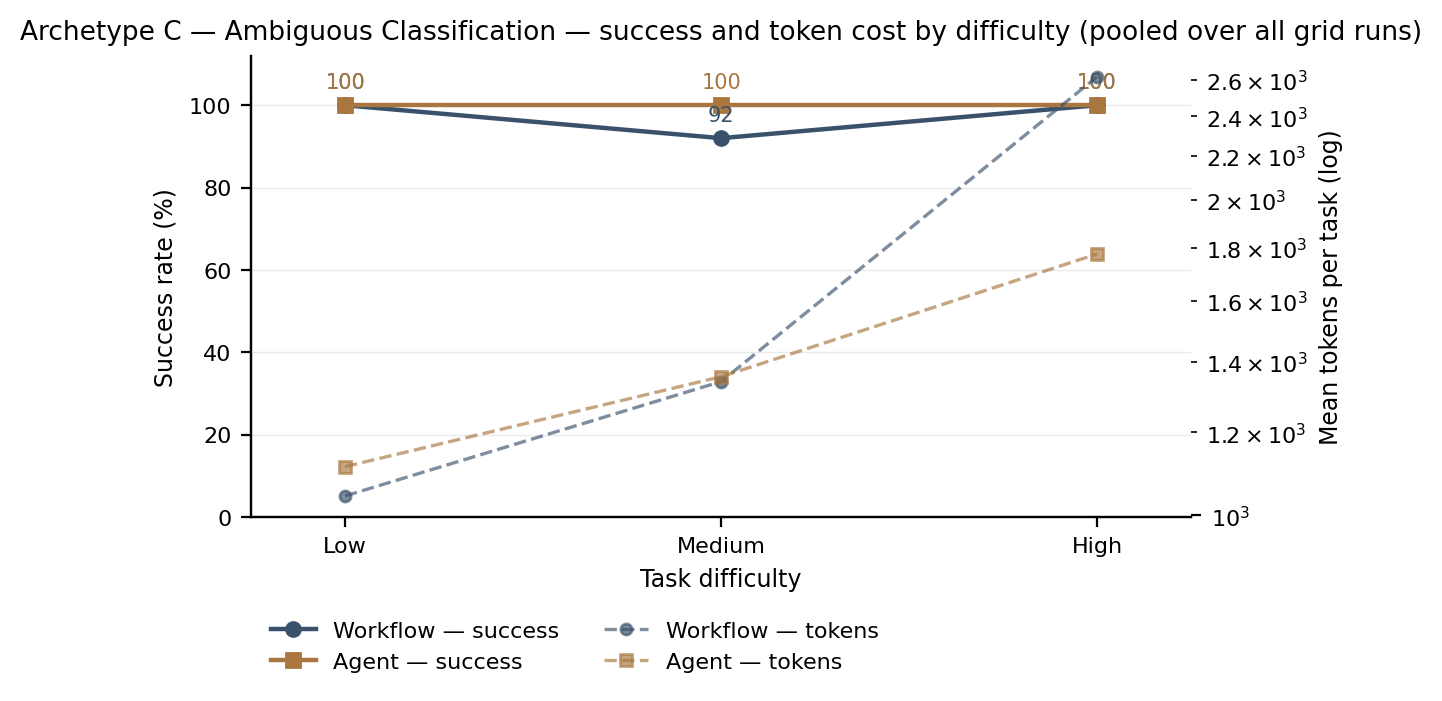

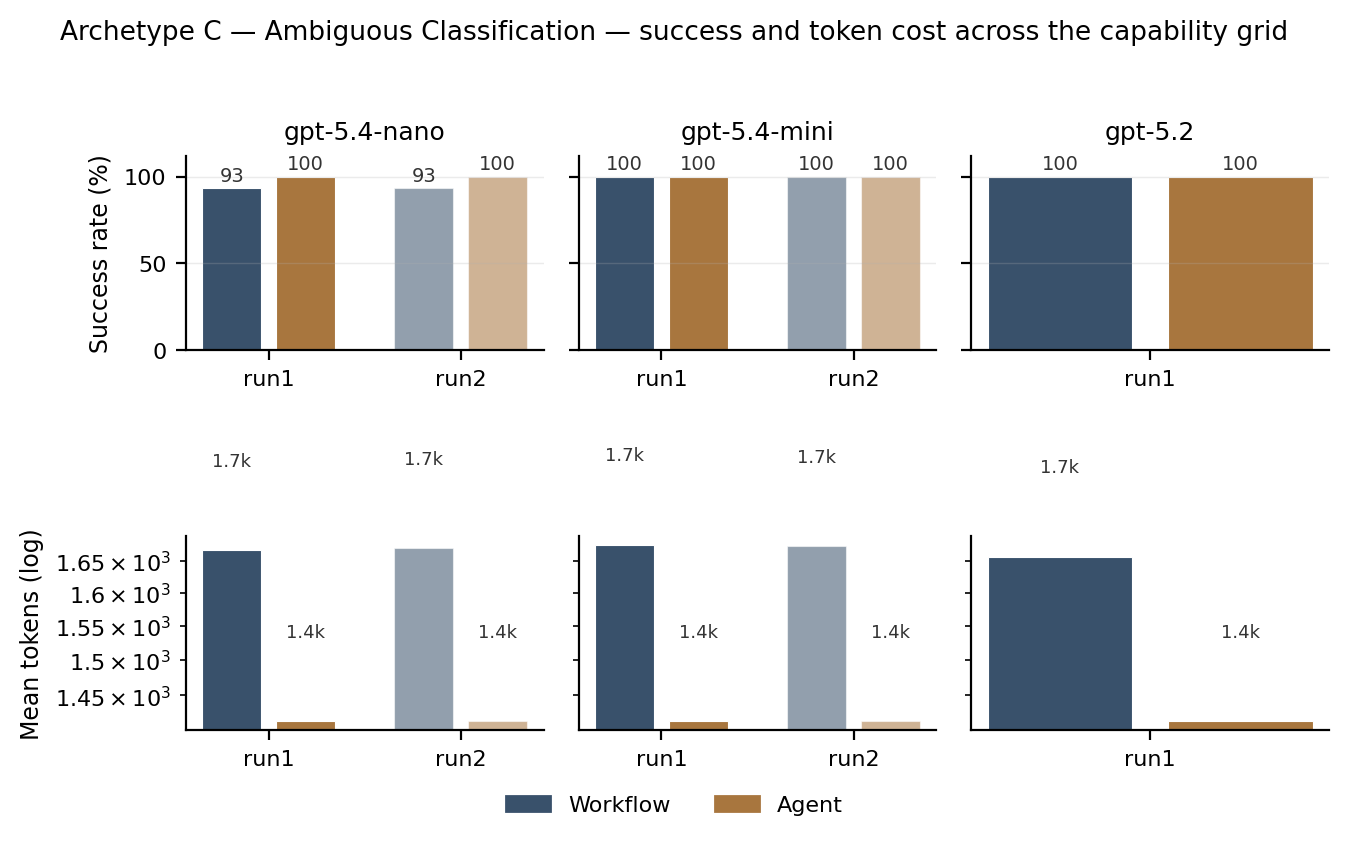

In [17]:
cell_table('C')
print()
difficulty_table('C')
print()
robustness_table('C')
fig('fig_diff_c')
fig('fig_c_ambiguous_classification')

### Findings C — Ambiguous Classification and Disambiguation

**Results.** Ceiling parity (W 98%, A 100%; 2 failures in 360 runs); the agent is *cheaper* at the high tier (1.8k vs 2.6k tokens, 0.8× overall). Zero tool calls in either paradigm; robustness 15/15 both.

**Interpretation.** Batch email triage is a single-step task: one classification pass, no retrieval, no branching (IT-040). The paradigm comparison is therefore degenerate — the only structural difference that remains is the workflow's fixed chunking, and that is pure overhead (IT-044), hence the inverted token ratio. C is the only archetype where the agent wins on cost.

**Open points.** As a degenerate single-step comparison, C discriminates weakly between paradigms; decide whether it enters the gate evidence with reduced weight, and treat context management (chunking) as a separate design concern orthogonal to the W/A decision (IT-044).

**TADF implication.** Either paradigm passes; route on the **structured-output guarantee** and operational needs (observability, batching), not on cost. Premature chunking should be a context-management parameter, not a paradigm property.


## Archetype D — Compliance and Rule-Based Decisioning

Rule reference: iteration-log TADF v1 rule block for D; figures `fig_diff_d.pdf` and `fig_d_compliance_decisioning.pdf`.

*What the next cell does:* it prints three tables for archetype D — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow     15/15      903
gpt-5.4-nano   run1   agent        11/15     5567
gpt-5.4-nano   run2   workflow     15/15      903
gpt-5.4-nano   run2   agent        12/15     5568
gpt-5.4-mini   run1   workflow     15/15      903
gpt-5.4-mini   run1   agent        11/15     5559
gpt-5.4-mini   run2   workflow     15/15      903
gpt-5.4-mini   run2   agent        12/15     5559
gpt-5.2        run1   workflow     15/15      903
gpt-5.2        run1   agent        14/15     5558

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow          100%         100%         100%
low    agent              70%         100%         100%
med    workflow          100%         100%         100%
med    agent              80%          50%         100%
high   workflow          100%         100%         100%
high   agent              80%          80%          80%

gpt-5.4-nano   workflow  6/6
gpt-5.4-nano   agent     5/

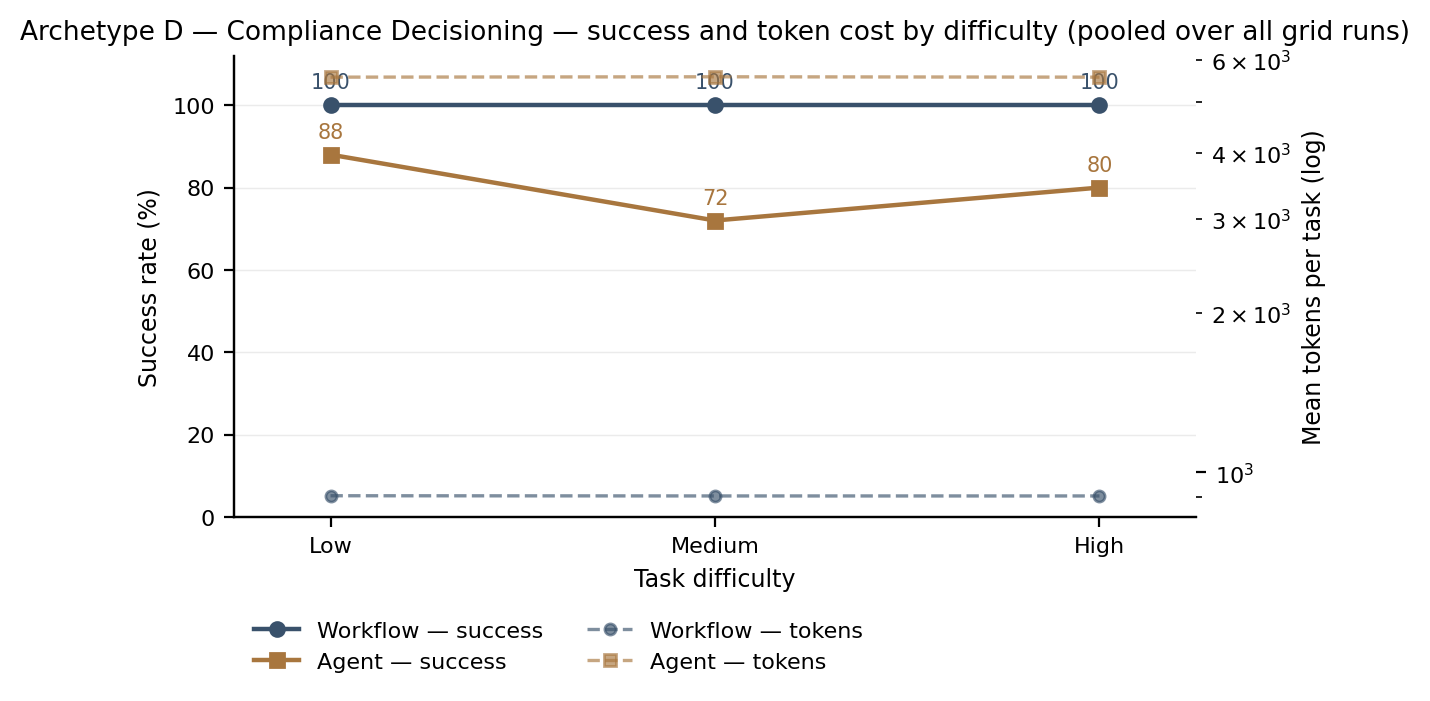

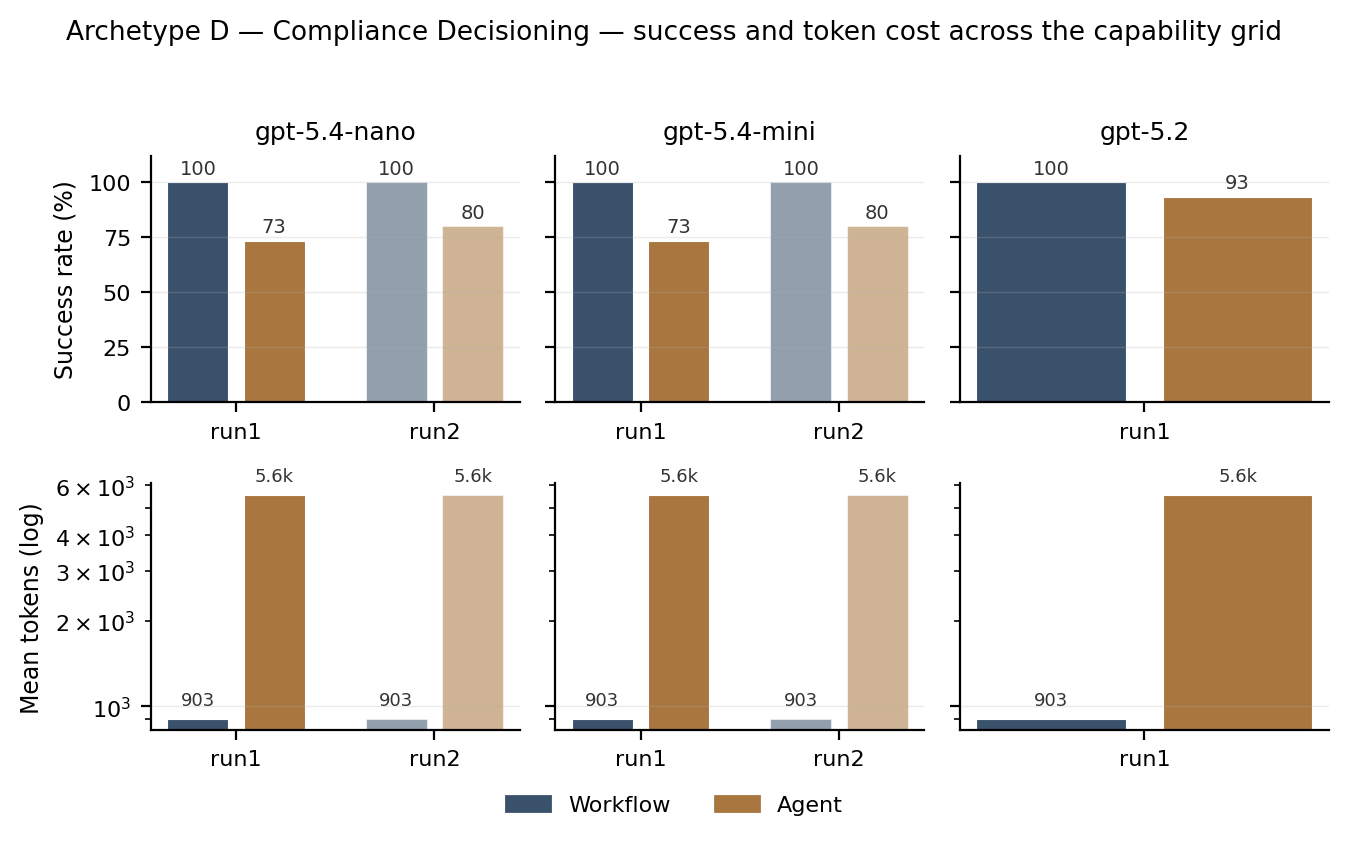

In [18]:
cell_table('D')
print()
difficulty_table('D')
print()
robustness_table('D')
fig('fig_diff_d')
fig('fig_d_compliance_decisioning')

### Findings D — Compliance and Rule-Based Decisioning

**Results.** Workflow 75/75 (100%) at **903 ± 4 tokens in every cell** — success *and* cost are rule-count-invariant across Low ~2 / Med ~5 / High ~10 combined rules (IT-045). Agent 60/75 (80%) at ~5.6k tokens (6.2×). Robustness: W 18/18 vs A 13/18.

**Error direction.** 12 of 15 agent errors are *permissive* (under-escalation) — 80% sit in the dangerous direction for a compliance task. The paradigms differ not only in error **rate** but in error **direction**, which is exactly the Error-Consequence dimension of the taxonomy made empirical.

**Interpretation.** Rules are fetched from the external policy store and applied by a deterministic engine (IT-041); the LLM only extracts case facts. The agent instead re-derives the rule logic in-context on every run and drops accumulation/interaction clauses as the ruleset grows (IT-021/IT-045) — its failure rate tracks rule complexity while the workflow's does not.

**Open points.** None blocking; D is the cleanest cell in the grid. Optionally quantify how agent under-escalation distributes over severity levels for the thesis discussion.

**TADF implication.** Strongest workflow-by-construction case (gate G2: codifiable, stable rules). Build note: externalize the rules and keep the model out of the decision step entirely — the near-deterministic 903-token cost is a direct consequence of that design.


## Archetype E — Output Verification and Quality Control

Rule reference: iteration-log TADF v1 rule block for E; figures `fig_diff_e.pdf` and `fig_e_output_verification.pdf`.

*What the next cell does:* it prints three tables for archetype E — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow     12/15     1360
gpt-5.4-nano   run1   agent        11/15     1282
gpt-5.4-nano   run2   workflow     10/15     1368
gpt-5.4-nano   run2   agent        12/15     1286
gpt-5.4-mini   run1   workflow     13/15     1355
gpt-5.4-mini   run1   agent         9/15     1123
gpt-5.4-mini   run2   workflow     11/15     1357
gpt-5.4-mini   run2   agent         8/15     1123
gpt-5.2        run1   workflow     13/15     1345
gpt-5.2        run1   agent        13/15     1268

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow           90%          80%          80%
low    agent              90%          60%         100%
med    workflow           80%          70%          80%
med    agent              70%          60%          80%
high   workflow           50%          90%         100%
high   agent              70%          50%          80%

gpt-5.4-nano   workflow  5/5
gpt-5.4-nano   agent     5/

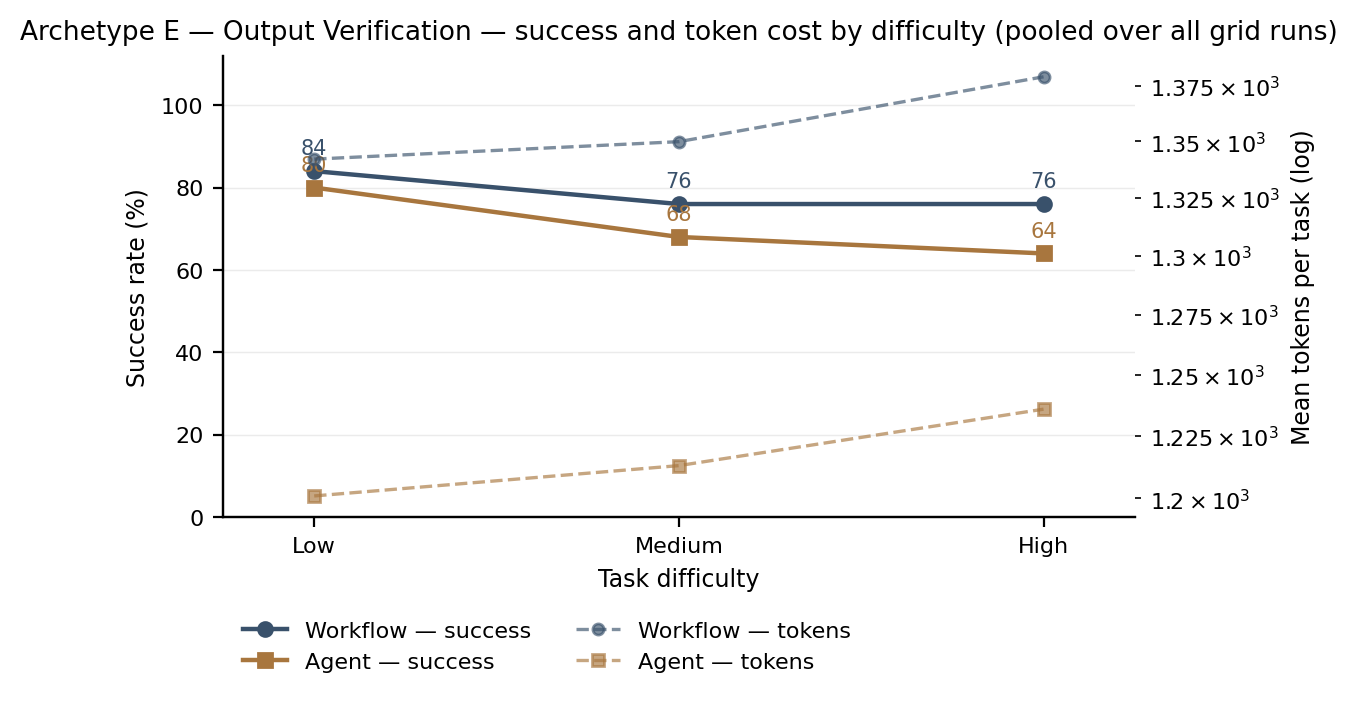

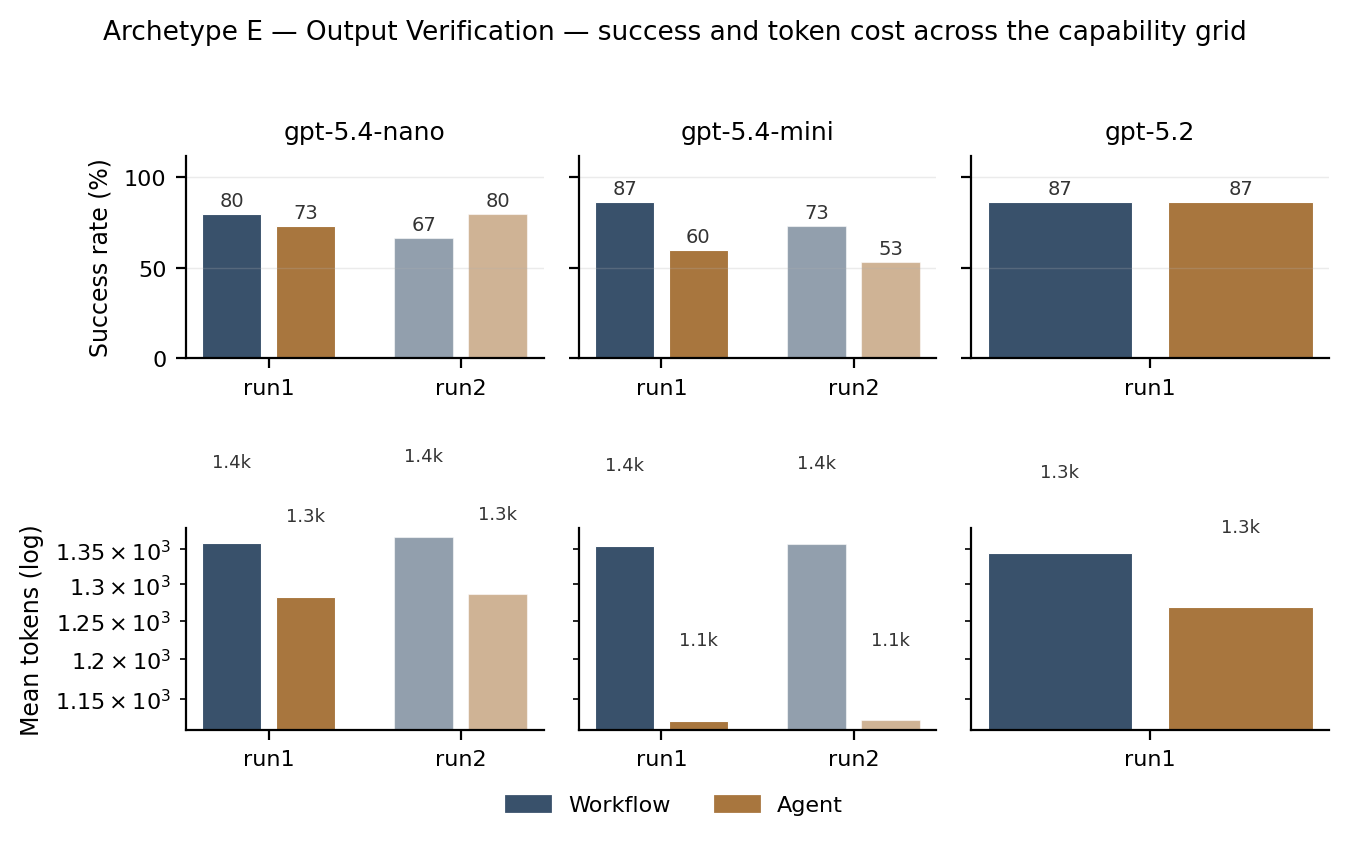

In [19]:
cell_table('E')
print()
difficulty_table('E')
print()
robustness_table('E')
fig('fig_diff_e')
fig('fig_e_output_verification')

### Findings E — Output Verification and Quality Control

**Results.** Near cost parity (~1.3k vs ~1.2k tokens, both tool-free). The high tier **flips sign with capability**: nano W 5/10 vs A 7/10, mini W 9/10 vs A 5/10, gpt-5.2 W 5/5 vs A 4/5 — the only sign flip in the entire grid (evidence item 7).

**Interpretation.** The decomposed-judgment workflow (per-criterion judgment + deterministic verdict engine, IT-046) only *binds* once the model can execute each criterion reliably; below that capability floor the decomposition adds structure the model cannot exploit, and the holistic agent judgment is the better use of the same budget. From the mid tier upward the workflow's structure dominates.

**Error direction.** Across 90 scored workflow artefacts: 35 false fails vs 17 missed fails — a systematic **2:1 strict bias**, not an exclusive error direction (supersedes the absolute claim of IT-046; the zero-missed-fails reading was nano-specific). For QC deployments strict bias is the safer direction, but it has a false-rejection cost.

**Open points.** Per-criterion failure census by tier; check whether mini-W 9/10 vs gpt-5.2-W 5/5 is a sample-size artifact (different n) before citing a non-monotonicity.

**TADF implication.** Model capability is a routing *input* (decision-tree stage 3): decomposed-judgment workflow from the mid tier upward; below it, no reliable configuration exists at this cost point — a capability floor, not a paradigm preference.


## Archetype F — Transactional Action Execution

Rule reference: iteration-log TADF v1 rule block for F; figures `fig_diff_f.pdf` and `fig_f_action_execution.pdf`.

*What the next cell does:* it prints three tables for archetype F — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow      7/15     3920
gpt-5.4-nano   run1   agent        10/15    18334
gpt-5.4-nano   run2   workflow      6/15     4392
gpt-5.4-nano   run2   agent        10/15    27766
gpt-5.4-mini   run1   workflow      7/15     3796
gpt-5.4-mini   run1   agent        12/15    13923
gpt-5.4-mini   run2   workflow      7/15     3854
gpt-5.4-mini   run2   agent        11/15    13243
gpt-5.2        run1   workflow      8/15     3873
gpt-5.2        run1   agent        12/15    12795

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow           80%          80%          80%
low    agent              80%          80%          80%
med    workflow           40%          60%          60%
med    agent              80%          80%          80%
high   workflow           10%           0%          20%
high   agent              40%          70%          80%

gpt-5.4-nano   workflow  3/5
gpt-5.4-nano   agent     5/

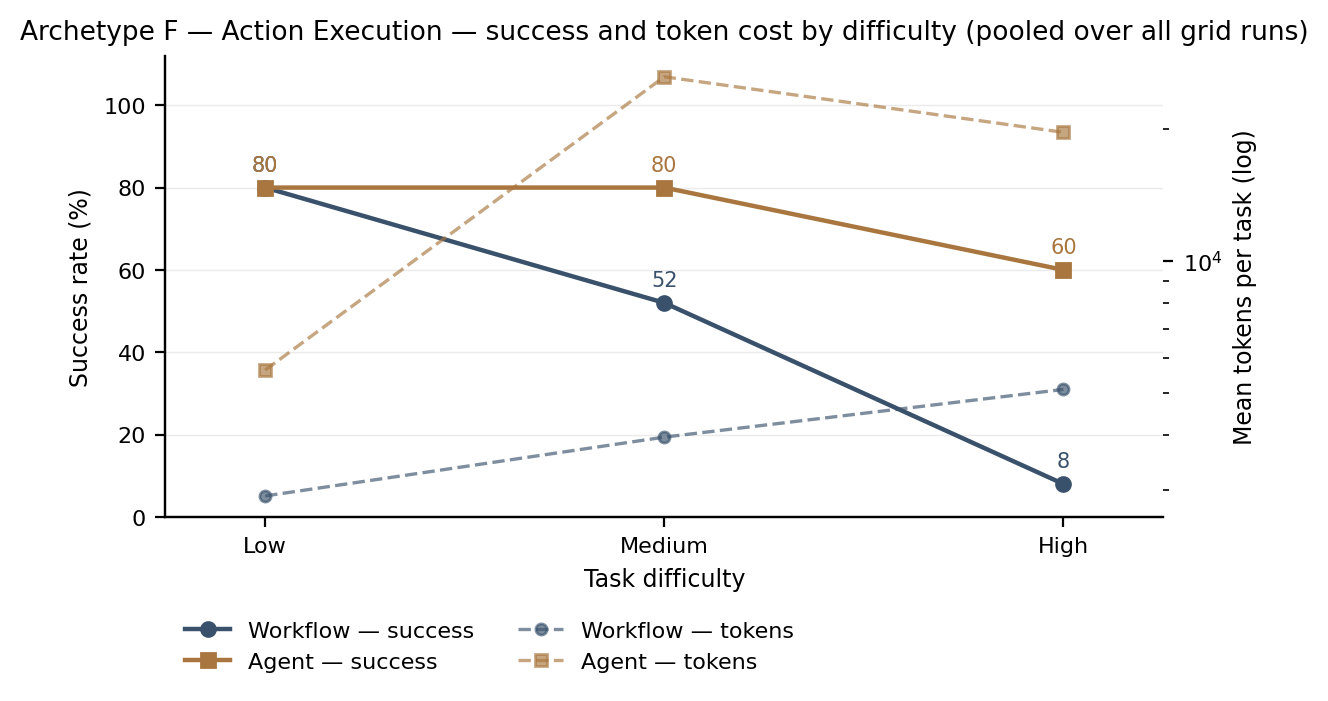

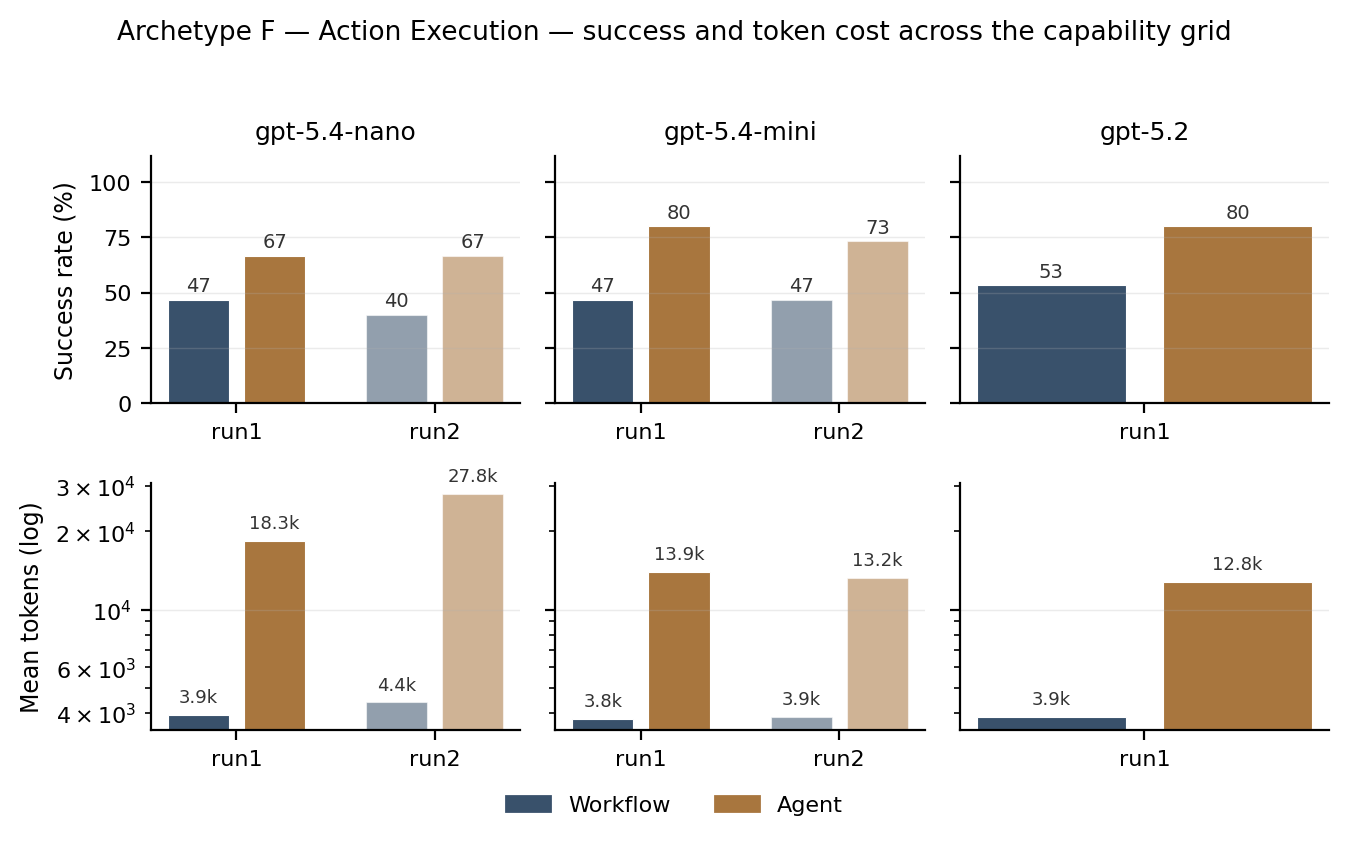

In [20]:
cell_table('F')
print()
difficulty_table('F')
print()
robustness_table('F')
fig('fig_diff_f')
fig('fig_f_action_execution')

### Findings F — Transactional Action Execution

**Results.** The largest paradigm gap in the grid: on the three designed runtime-feedback instances the workflow scores **0/15** vs agent **13/15** (87 pts), invariant across all capability tiers (gate G1). The same workflow scores 35/60 on plan-time instances — the *mechanism*, not the archetype, carries the gap. Agent med-tier cost ≈ 26k tokens (retry loops). Robustness: W 13/15 vs A 15/15.

**Conditional branching generally.** The read-conditional `f-med-2`, hypothesized workflow-feasible, is refuted by the grid: W 1/5 vs A 5/5 including mini and gpt-5.2. Conditional branching *as such* — not only action-outcome branching — breaks the two-stage plan→execute form (supersedes reading (a) of IT-047/IT-049).

**Enumeration is heterogeneity-conditional (G4).** Nine *heterogeneous* reassignments (`f-med-3`): W 2/5 vs A 5/5. Sixteen *identical* updates (`f-med-4`): 5/5 for both. Seven recipients needing per-target resolution (`f-med-5`): 0/5 for both — instance-level saturation. The structured-output ceiling binds on argument heterogeneity, not raw count; the nano `ActionPlan` validation crashes (153 and 18 validation errors) are that ceiling made visible.

**Open points.** Workflow traces on runtime instances include executing the explicitly *prohibited* recovery action (IT-047) — cheap but wrong, and an error-consequence argument against forcing workflows here; document one trace for 4.5. Decompose-and-retry design for `f-med-5`-type instances.

**TADF implication.** Four-quadrant rule (IT-015/IT-047): plan-time-decidable / small homogeneous set → workflow; runtime-observed results or heterogeneous enumeration → agent. Build notes: iteration caps (recursion crashes), guardrails on prohibited actions, and a schema-complexity budget for plan objects.


## Archetype G — Strategic and Adaptive Planning

Rule reference: iteration-log TADF v1 rule block for G; figures `fig_diff_g.pdf` and `fig_g_strategic_planning.pdf`.

*What the next cell does:* it prints three tables for archetype G — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow      7/15     3906
gpt-5.4-nano   run1   agent         8/15    12156
gpt-5.4-nano   run2   workflow      8/15     4449
gpt-5.4-nano   run2   agent         8/15    20739
gpt-5.4-mini   run1   workflow     10/15     3138
gpt-5.4-mini   run1   agent        13/15     7369
gpt-5.4-mini   run2   workflow     10/15     3179
gpt-5.4-mini   run2   agent        13/15     7129
gpt-5.2        run1   workflow     11/15     3391
gpt-5.2        run1   agent        14/15     4859

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow           60%          60%          80%
low    agent              80%          90%         100%
med    workflow           70%          80%          80%
med    agent              50%         100%         100%
high   workflow           20%          60%          60%
high   agent              30%          70%          80%

gpt-5.4-nano   workflow  6/6
gpt-5.4-nano   agent     4/

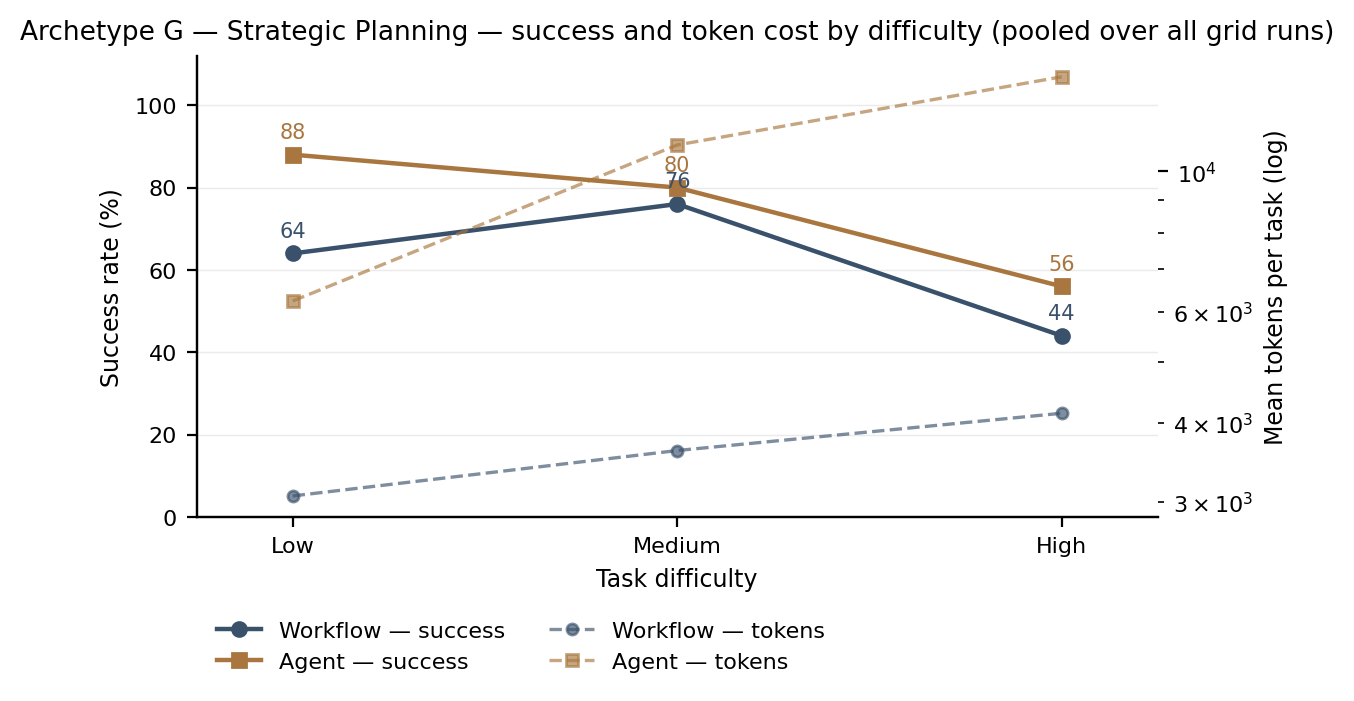

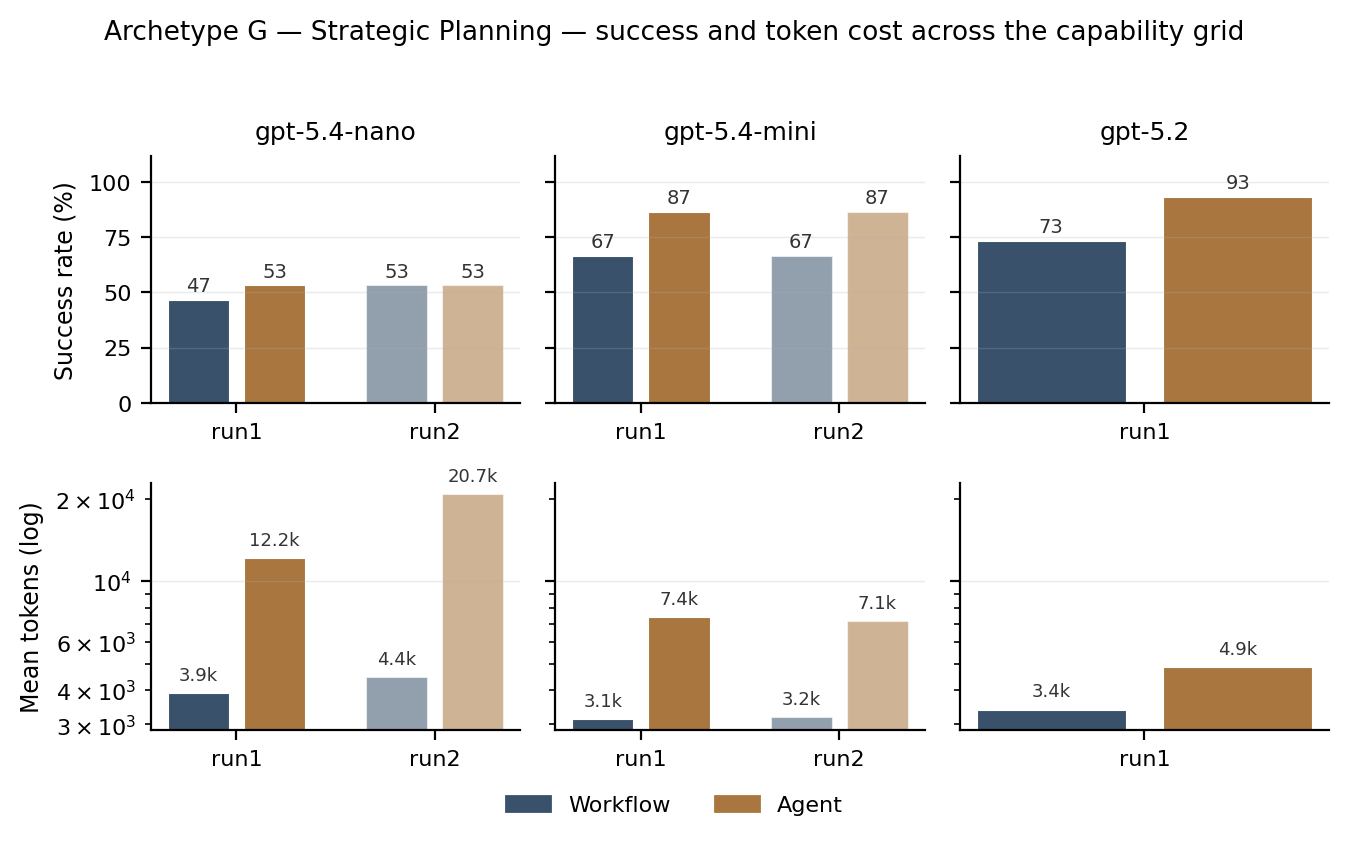

In [21]:
cell_table('G')
print()
difficulty_table('G')
print()
robustness_table('G')
fig('fig_diff_g')
fig('fig_g_strategic_planning')

### Findings G — Strategic and Adaptive Planning

**Results.** The agent leads every tier (88/80/56 vs 64/76/44); overall W 68% vs A 77% — the Table-3 routing hypothesis confirmed (IT-024). Robustness near-parity (W 17/18 vs A 16/18).

**Failure signatures are paradigm-diagnostic (evidence item 11).** Workflow failures concentrate on recipient resolution (`emails`: 28) with **zero** ordering violations — a fixed pipeline cannot emit out-of-order plans. The agent violates ordering 4× and spreads across categories. Practical consequence: the workflow's deficit is a *resolution subtask*, not planning per se — a hybrid (workflow + resolution tool/loop) is the obvious design response.

**Cost discrepancy (open).** In this grid the agent's token premium *rises* with tier (2.0× → 3.0× → 3.4× on per-run averages), whereas the earlier reading reported a *falling* premium (3.9× → 1.4×). The earlier figure was per *solved* task and pre-rework; re-derive tokens-per-solved-task per tier from this grid before quoting either number in 4.5.

**Open points.** nano runbook argument-binding failures (IT-051) — a capability floor for agentic planning below the mini tier; check how many agent ordering violations cluster in the high tier.

**TADF implication.** Adaptive multi-step planning → agent; templated processes remain workflow candidates. The constraint-type census, not the aggregate rate, should drive the hybrid design guidance.


## Archetype H — Content and Document Drafting

Rule reference: iteration-log TADF v1 rule block for H; figures `fig_diff_h.pdf` and `fig_h_content_drafting.pdf`.

*What the next cell does:* it prints three tables for archetype H — (1) per-model success counts and average token cost on the clean runs, (2) success rate broken down by difficulty tier (low / med / high) for each paradigm and model, and (3) success on the robustness (perturbed-input) runs — then displays the two thesis figures for this archetype (the paradigm-difference plot and the summary plot).

model          run    paradigm   success  avg_tok
gpt-5.4-nano   run1   workflow      7/15     1688
gpt-5.4-nano   run1   agent         5/15     2943
gpt-5.4-nano   run2   workflow      7/15     1691
gpt-5.4-nano   run2   agent         4/15     2501
gpt-5.4-mini   run1   workflow      9/15     1708
gpt-5.4-mini   run1   agent         7/15     2216
gpt-5.4-mini   run2   workflow      9/15     1690
gpt-5.4-mini   run2   agent         8/15     1987
gpt-5.2        run1   workflow      8/15     1794
gpt-5.2        run1   agent         5/15     3099

tier   paradigm  gpt-5.4-nano gpt-5.4-mini      gpt-5.2
low    workflow           70%         100%          80%
low    agent              80%          80%          80%
med    workflow           70%          80%          60%
med    agent              10%          70%          20%
high   workflow            0%           0%          20%
high   agent               0%           0%           0%

gpt-5.4-nano   workflow  4/5
gpt-5.4-nano   agent     4/

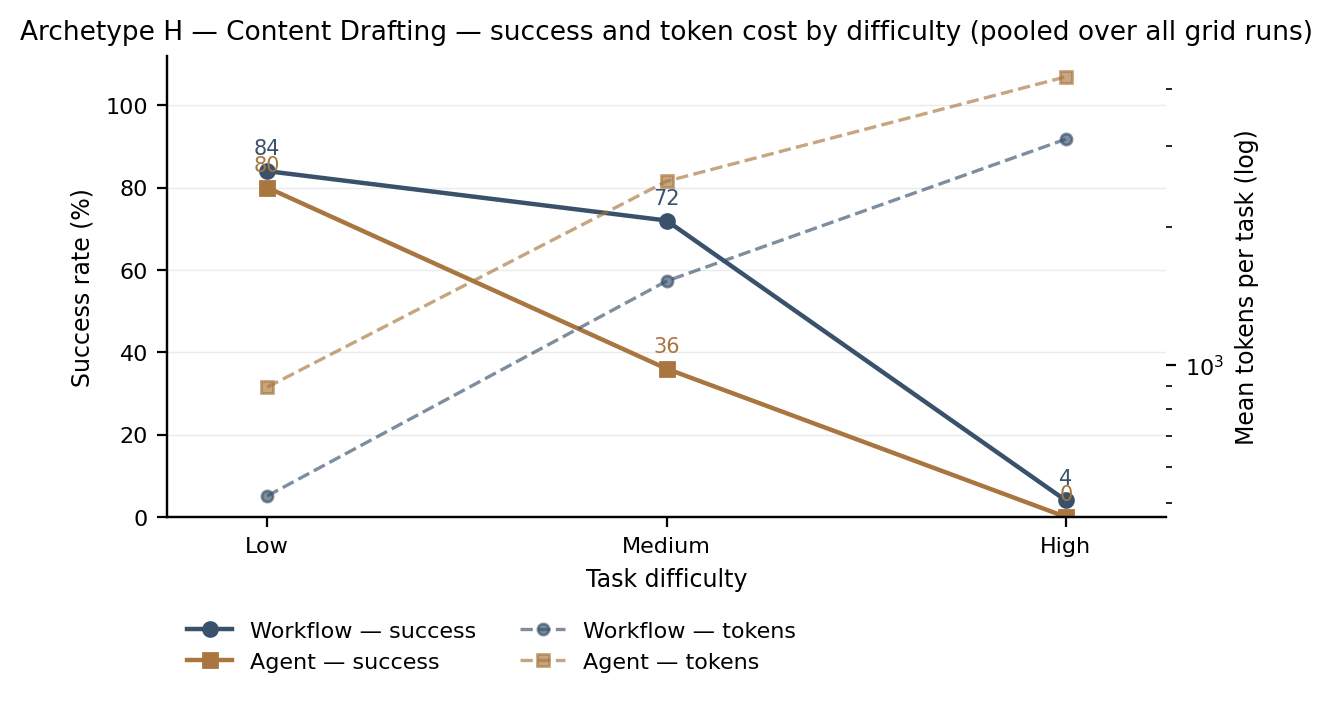

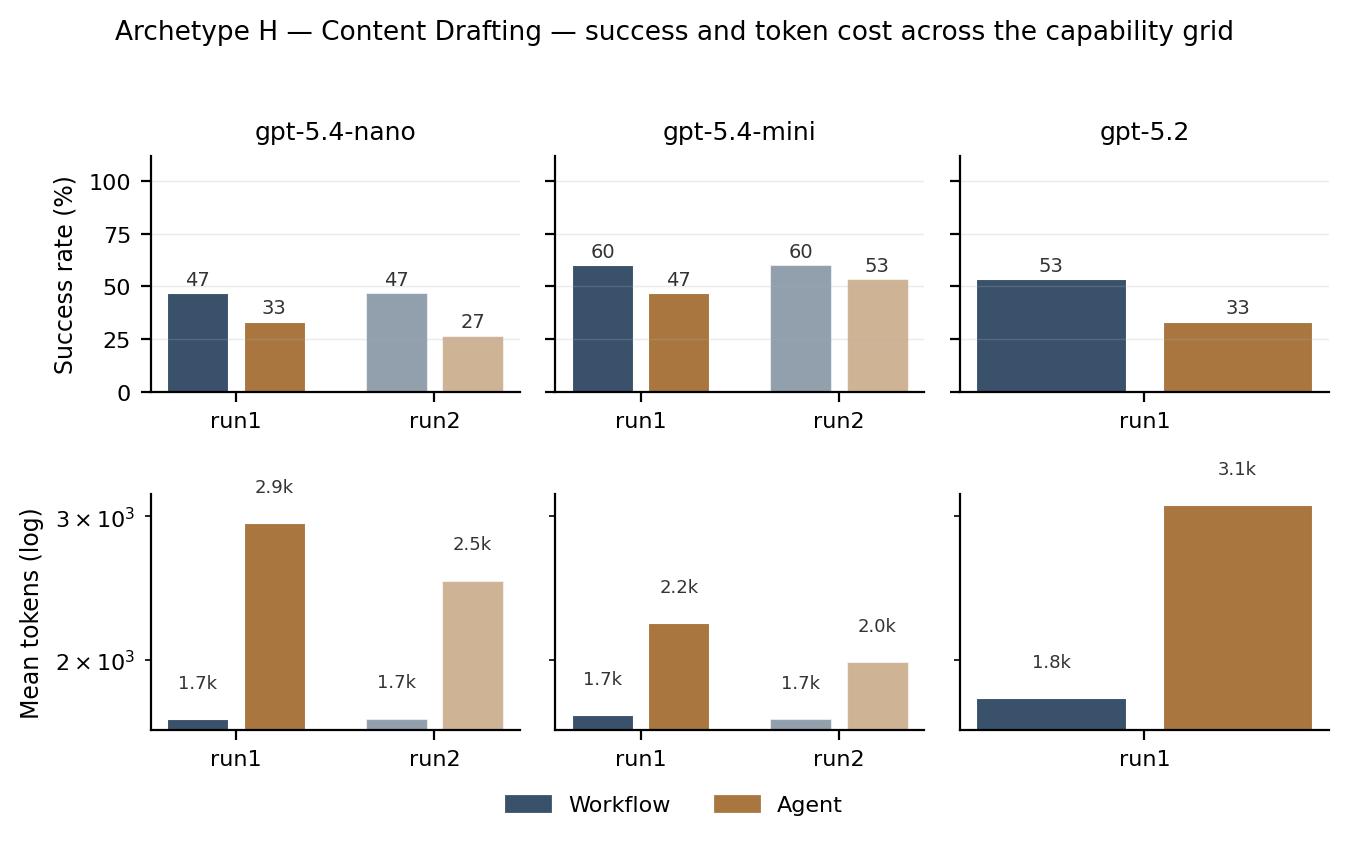

In [22]:
cell_table('H')
print()
difficulty_table('H')
print()
robustness_table('H')
fig('fig_diff_h')
fig('fig_h_content_drafting')

### Findings H — Content and Document Drafting

**Results.** The workflow leads all tiers (84/72/4 vs 80/36/0). The high tier is **saturated for both** (1/25 vs 0/25: six-plus simultaneous constraints with rework rounds) — with B-high, the second saturation cell in the grid. Robustness 13/15 both.

**Over-revision decay (evidence item 12).** Agent compliance by self-revision turns: 1 turn 90% → 2 turns 47% → 3 turns 8% → 4 turns 0% — monotone. Each unforced revision is an opportunity to break a previously satisfied constraint; the med-tier collapse (36% vs workflow 72%) is this mechanism, not a knowledge gap. (Confounded with tier, since feedback rounds force turns — but the direction is unambiguous.)

**Judge vs deterministic layer.** The frozen judge misses what the deterministic compliance layer catches in 11% of clean artefacts (17/150); casual briefs induce arithmetic fabrication that *only* the deterministic layer catches (IT-052). The dual-scoring design is load-bearing, not redundant.

**Open points.** H is tool-free by design (IT-052 legitimizes the tool-free agent within the paradigm definition) — state this in 4.5 so the W/A contrast is read as fixed-pass vs self-revision-loop, not tools vs no-tools. Decomposition pilot for the high tier.

**TADF implication.** Constraint-heavy drafting → workflow with deterministic compliance checks and a **hard cap on revision turns**; six-plus simultaneous constraints → decompose (saturation, the third routing outcome).


## Cross-cutting gate evidence

*What the next cell does:* it runs the full gate-statistics script (`experiments/analyze_evidence.py`) and prints the exact numbers behind the framework's decision gates — the same figures reported in `docs/evidence_summary.md`. Use this to cross-check any number quoted in the thesis.

In [23]:
from experiments.analyze_evidence import main as evidence
evidence()

G1 runtime feedback (f-high-1/2/5):
  workflow: 0/15
  agent: 13/15
G1 correction, read-conditional f-med-2:
  workflow: 1/5
  agent: 5/5
G2 rule application (D):
  workflow: 75/75, tokens 903 +/- 4
  agent: 60/75, tokens 5562 +/- 23
  agent errors 15, permissive 12
G3 chained search (A high, provider errors excluded):
  workflow: 14/25
  agent: 23/25
G4 enumeration (heterogeneous vs identical):
  f-med-3 workflow: 2/5
  f-med-3 agent: 5/5
  f-med-5 workflow: 0/5
  f-med-5 agent: 0/5
  f-med-4 workflow: 5/5
  f-med-4 agent: 5/5
Saturation (H-high, B-high):
  H-high workflow: 1/25
  H-high agent: 0/25
  B-high workflow: 8/25
  B-high agent: 10/25
E-high capability switch:
  gpt-5.2-2025-12-11 workflow: 5/5
  gpt-5.2-2025-12-11 agent: 4/5
  gpt-5.4-mini-2026-03-17 workflow: 9/10
  gpt-5.4-mini-2026-03-17 agent: 5/10
  gpt-5.4-nano-2026-03-17 workflow: 5/10
  gpt-5.4-nano-2026-03-17 agent: 7/10
Deep patterns:
  temp-0 flip rate: 49/480 = 10.2%
  tokens per SOLVED task:
    A: W=7547 A=135

## Synthesis

**Transition typology** (how the W/A ranking changes across the grid):

- **Mechanism switch** — F: runtime-observed results break the plan→execute form at *every* capability tier (0/15 vs 13/15); the gap is structural, not statistical.
- **Capability switch** — E-high: the decomposed-judgment workflow binds only from the mid tier upward; the grid's only sign flip.
- **Magnitude convergence** — A: the success gap shrinks 60 → 20 pts with capability but never flips; cost gaps in G narrow without changing the ranking.
- **Saturation** — H-high, B-high, `f-med-5`: neither paradigm carries the cell; the evidenced answer is **decomposition**, a third routing outcome beyond workflow/agent.

**Decision sequence supported by this grid** (feeds the TADF v1 decision tree): G1 runtime-observed results → agent · G2 codifiable stable rules → workflow · G3 open chained search → agent · G4 heterogeneous enumeration → agent (identical bulk → workflow) · saturation signals → decompose · capability stage: check the model floor (E, IT-043/047/051) before finalizing.

**Cost logic.** Workflow cost is difficulty-invariant wherever a deterministic middle layer exists (B ~2.1k flat, D 903 ± 4); agent cost scales with observation volume and retries (B-high 32k, F-med 26k). The agent premium (2.6–3.5× per model) is justified exactly where a gate fires — where it does not (D, H), the premium buys a *worse* result.

**Build knowledge (design theory for 4.5 / Ch. 6):** deterministic layers (query executor, rule engine, verdict engine, compliance checks) carry the workflow advantage and make its cost predictable; the workflow's ceiling is structured-output schema complexity (validation crashes on heterogeneous plans); the agent's ceilings are iteration control (recursion overflows), prohibited-action discipline, and over-revision; memorization must be re-checked per model for retrieval archetypes (A); all single-run readings are bounded by the 10.2% temperature-0 flip rate — pattern claims only.

*(Konsolidierte Schlussfolgerungen für Kapitel 4.5 / Framework — cross-check every number via the gate-evidence cell above.)*


## 4. TADF v1 — the architect's decision tree

This section turns the findings above into the routing artifact itself. Intended use: you are composing a **larger automation pipeline**; for **each task node** in that pipeline you walk the gates top-to-bottom and take the first leaf that fires. The gates are ordered by the strength of the evidence behind them (structural > rule-based > search > enumeration), and *decompose* is a first-class third outcome — if a task trips the saturation check, split it and re-enter the tree per subtask.

Quick lookup by archetype (details in Section 3):

| Task looks like | Archetype | Default route |
|---|---|---|
| Open research, answer must be retrieved | A | Agent (low tier + low error consequence: workflow) |
| Structured retrieval / transformation | B | Workflow with deterministic executor (compound output → decompose) |
| Single-pass classification / triage | C | Either — route on structured-output guarantee |
| Rule-based decisioning / compliance | D | Workflow with deterministic rule engine |
| Output verification / QC | E | Workflow (decomposed judgment) from mid model tier |
| Transactional action execution | F | Four-quadrant: gates G1/G4 decide |
| Adaptive multi-step planning | G | Agent (templated processes: workflow) |
| Constraint-heavy drafting | H | Workflow + revision cap (≥6 constraints → decompose) |

*What the next cell does:* it draws the decision tree in the house style — gates on the left, leaves on the right. Each gate states the test twice: as the routing question, and as the concrete task property an architect checks against the task description. Leaves name the mechanism, the grid evidence (with archetype anchors for traceability to Section 3), and the build notes (blue = workflow, purple = agent, amber = decompose), each leaf annotated with the grid evidence and its build notes. The capability band at the bottom applies to **every** leaf.


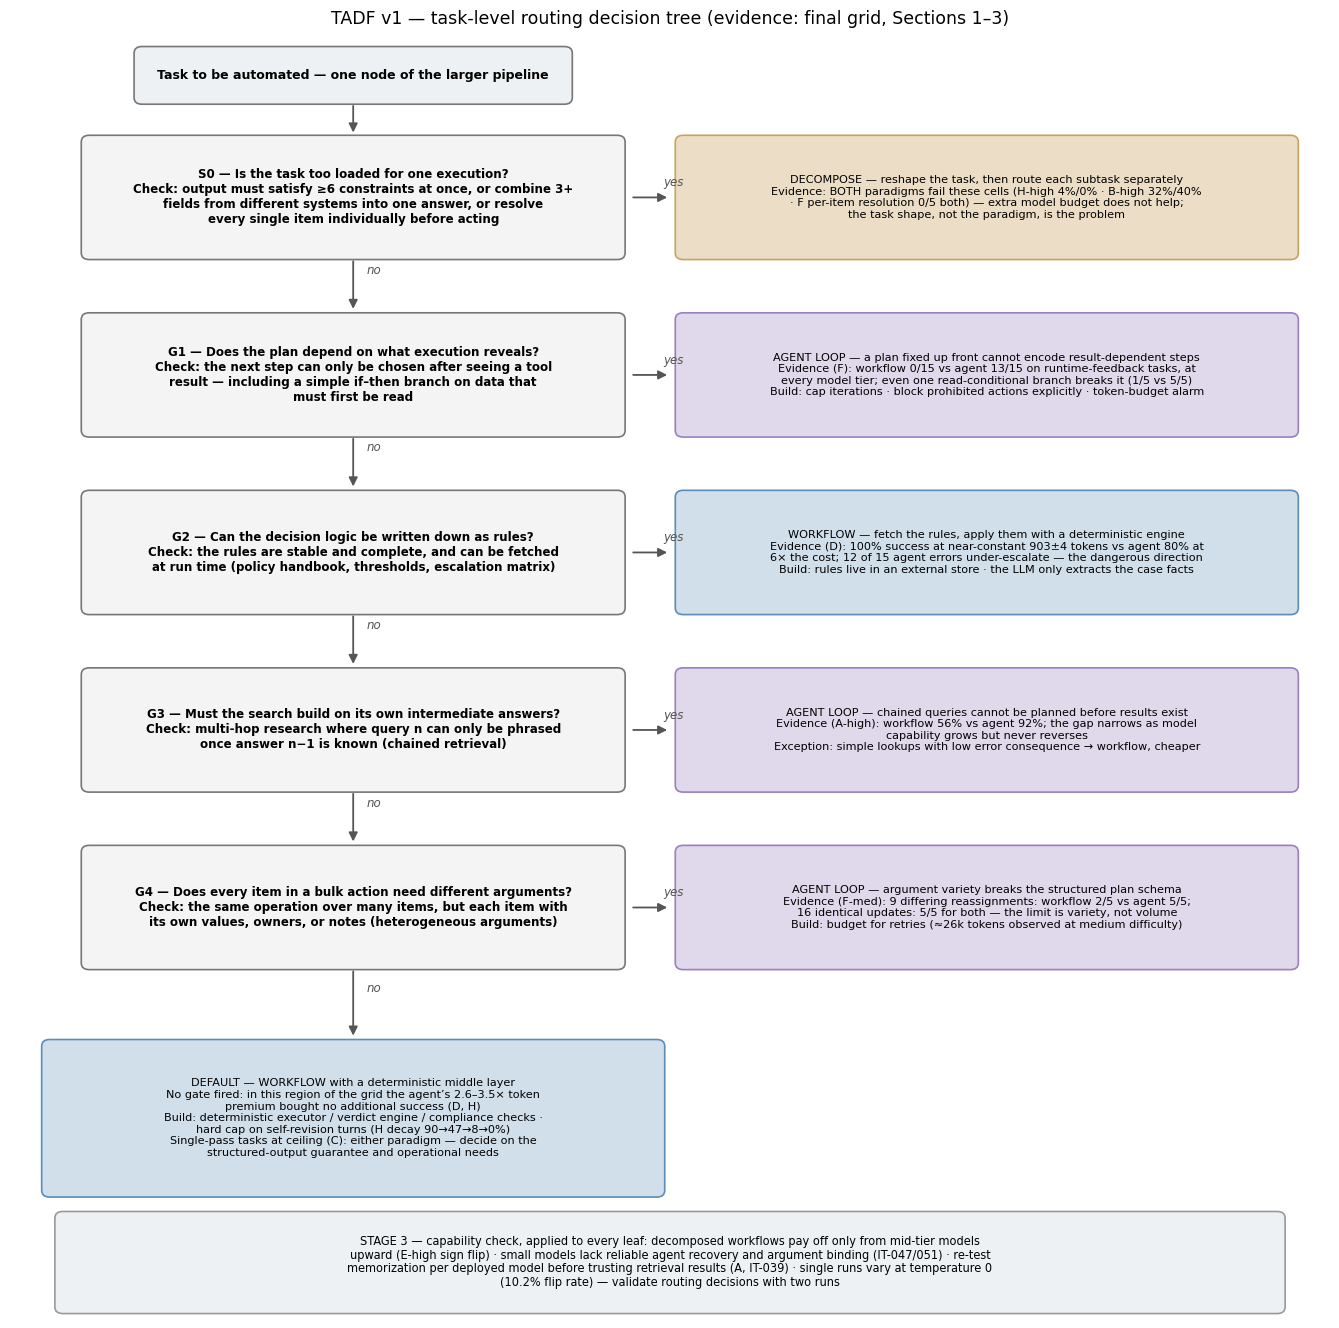

In [24]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

C_DC='#c9a25e'; C_GT='#f4f4f4'; C_EI='#eef1f3'   # decompose amber, gate grey, neutral

def _node(ax,x,y,w,h,text,fc,ec='#777',fs=8.1,weight='normal'):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.6',
                                fc=fc,ec=ec,lw=1.2,zorder=2))
    ax.text(x,y,text,ha='center',va='center',fontsize=fs,zorder=3,fontweight=weight)

def _arrow(ax,x1,y1,x2,y2,label=''):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=13,
                                 color='#555',lw=1.3,zorder=1))
    if label: ax.text((x1+x2)/2+1.0,(y1+y2)/2+1.0,label,fontsize=8.5,color='#555',
                      ha='left',fontstyle='italic')

f,ax=plt.subplots(figsize=(13.5,13.5))
ax.set_xlim(0,100); ax.set_ylim(0,116); ax.axis('off')
GX, LX = 26, 74            # gate column / leaf column
tint=lambda c,a: (*plt.matplotlib.colors.to_rgb(c),a)
T_WF=tint(C_WF,0.28); T_AG=tint(C_AG,0.30)

_node(ax,GX,112,32,4,'Task to be automated — one node of the larger pipeline',C_EI,fs=9,weight='bold')

# ---- S0 saturation ----
_node(ax,GX,101,40,10,'S0 — Is the task too loaded for one execution?\n'
      'Check: output must satisfy \u22656 constraints at once, or combine 3+\n'
      'fields from different systems into one answer, or resolve\n'
      'every single item individually before acting',C_GT,fs=8.5,weight='bold')
_node(ax,LX,101,46,10,'DECOMPOSE — reshape the task, then route each subtask separately\n'
      'Evidence: BOTH paradigms fail these cells (H-high 4%/0% \u00b7 B-high 32%/40%\n'
      '\u00b7 F per-item resolution 0/5 both) — extra model budget does not help;\n'
      'the task shape, not the paradigm, is the problem',tint(C_DC,0.35),ec=C_DC)
_arrow(ax,GX,109.5,GX,106.6); _arrow(ax,GX+21,101,LX-24,101,'yes')

# ---- G1 runtime feedback ----
_node(ax,GX,85,40,10,'G1 — Does the plan depend on what execution reveals?\n'
      'Check: the next step can only be chosen after seeing a tool\n'
      'result — including a simple if\u2013then branch on data that\n'
      'must first be read',C_GT,fs=8.5,weight='bold')
_node(ax,LX,85,46,10,'AGENT LOOP — a plan fixed up front cannot encode result-dependent steps\n'
      'Evidence (F): workflow 0/15 vs agent 13/15 on runtime-feedback tasks, at\n'
      'every model tier; even one read-conditional branch breaks it (1/5 vs 5/5)\n'
      'Build: cap iterations \u00b7 block prohibited actions explicitly \u00b7 token-budget alarm',T_AG,ec=C_AG)
_arrow(ax,GX,95.5,GX,90.7,'no'); _arrow(ax,GX+21,85,LX-24,85,'yes')

# ---- G2 codifiable rules ----
_node(ax,GX,69,40,10,'G2 — Can the decision logic be written down as rules?\n'
      'Check: the rules are stable and complete, and can be fetched\n'
      'at run time (policy handbook, thresholds, escalation matrix)',C_GT,fs=8.5,weight='bold')
_node(ax,LX,69,46,10,'WORKFLOW — fetch the rules, apply them with a deterministic engine\n'
      'Evidence (D): 100% success at near-constant 903\u00b14 tokens vs agent 80% at\n'
      '6\u00d7 the cost; 12 of 15 agent errors under-escalate — the dangerous direction\n'
      'Build: rules live in an external store \u00b7 the LLM only extracts the case facts',T_WF,ec=C_WF)
_arrow(ax,GX,79.5,GX,74.7,'no'); _arrow(ax,GX+21,69,LX-24,69,'yes')

# ---- G3 chained search ----
_node(ax,GX,53,40,10,'G3 — Must the search build on its own intermediate answers?\n'
      'Check: multi-hop research where query n can only be phrased\n'
      'once answer n\u22121 is known (chained retrieval)',C_GT,fs=8.5,weight='bold')
_node(ax,LX,53,46,10,'AGENT LOOP — chained queries cannot be planned before results exist\n'
      'Evidence (A-high): workflow 56% vs agent 92%; the gap narrows as model\n'
      'capability grows but never reverses\n'
      'Exception: simple lookups with low error consequence \u2192 workflow, cheaper',T_AG,ec=C_AG)
_arrow(ax,GX,63.5,GX,58.7,'no'); _arrow(ax,GX+21,53,LX-24,53,'yes')

# ---- G4 heterogeneous enumeration ----
_node(ax,GX,37,40,10,'G4 — Does every item in a bulk action need different arguments?\n'
      'Check: the same operation over many items, but each item with\n'
      'its own values, owners, or notes (heterogeneous arguments)',C_GT,fs=8.5,weight='bold')
_node(ax,LX,37,46,10,'AGENT LOOP — argument variety breaks the structured plan schema\n'
      'Evidence (F-med): 9 differing reassignments: workflow 2/5 vs agent 5/5;\n'
      '16 identical updates: 5/5 for both — the limit is variety, not volume\n'
      'Build: budget for retries (\u224826k tokens observed at medium difficulty)',T_AG,ec=C_AG)
_arrow(ax,GX,47.5,GX,42.7,'no'); _arrow(ax,GX+21,37,LX-24,37,'yes')

# ---- default leaf ----
_node(ax,GX,18,46,13,'DEFAULT — WORKFLOW with a deterministic middle layer\n'
      'No gate fired: in this region of the grid the agent\u2019s 2.6\u20133.5\u00d7 token\n'
      'premium bought no additional success (D, H)\n'
      'Build: deterministic executor / verdict engine / compliance checks \u00b7\n'
      'hard cap on self-revision turns (H decay 90\u219247\u21928\u21920%)\n'
      'Single-pass tasks at ceiling (C): either paradigm — decide on the\n'
      'structured-output guarantee and operational needs',T_WF,ec=C_WF)
_arrow(ax,GX,31.5,GX,25.2,'no')

# ---- capability band ----
_node(ax,50,5,92,8,'STAGE 3 — capability check, applied to every leaf: decomposed workflows pay off only from mid-tier models\n'
      'upward (E-high sign flip) \u00b7 small models lack reliable agent recovery and argument binding (IT-047/051) \u00b7 re-test\n'
      'memorization per deployed model before trusting retrieval results (A, IT-039) \u00b7 single runs vary at temperature 0\n'
      '(10.2% flip rate) — validate routing decisions with two runs',C_EI,ec='#999',fs=8.2)

f.suptitle('TADF v1 — task-level routing decision tree (evidence: final grid, Sections 1\u20133)',fontsize=12.5)
plt.tight_layout(); plt.show()


*What the next cell does:* it implements the tree as a callable checker, `route_task(...)`. When composing a pipeline, describe each task node with the keyword flags (they mirror the gate questions) and the function prints the fired gate, the routing decision, the grid evidence behind it, and the paradigm-specific build notes. This is the task-by-task walkthrough in executable form; the demo below routes a realistic six-task pipeline.


In [25]:
def route_task(name, *, constraints=0, compound_multi_system=False, per_item_resolution=False,
               runtime_feedback=False, codifiable_rules=False, chained_search=False,
               heterogeneous_enumeration=False, error_consequence='moderate',
               difficulty='med', model_tier='mid'):
    """Walk one pipeline task through the TADF v1 gates (first gate that fires wins).

    Flags mirror the tree: constraints (count of simultaneous output constraints),
    compound_multi_system (one answer combining 3+ fields across systems),
    per_item_resolution (every item needs its own lookup), runtime_feedback
    (next step depends on observed results / read-conditional branching),
    codifiable_rules, chained_search (hop n depends on hop n-1),
    heterogeneous_enumeration (bulk action, per-item different arguments).
    error_consequence/difficulty/model_tier: 'low' | 'moderate'/'med' | 'high'.
    """
    notes=[]
    if constraints>=6 or compound_multi_system or per_item_resolution:
        gate,verdict='S0 saturation','DECOMPOSE'
        ev='H-high 1/25 vs 0/25 · B-high 8/25 vs 10/25 · f-med-5 0/5 both'
        notes.append('split into subtasks and re-enter the tree per subtask')
    elif runtime_feedback:
        gate,verdict='G1 runtime-observed results','AGENT'
        ev='F runtime: W 0/15 vs A 13/15 (tier-invariant) · f-med-2: 1/5 vs 5/5'
        notes+=['set an iteration cap (recursion overflow is THE agent crash mode)',
                'guard prohibited/irreversible actions explicitly (IT-047 trace)']
    elif codifiable_rules:
        gate,verdict='G2 codifiable stable rules','WORKFLOW'
        ev='D: W 75/75 @ 903±4 tok vs A 60/75 @ 5.6k · 12/15 agent errors permissive'
        notes+=['externalize rules to a policy store; apply them deterministically',
                'keep the LLM to fact extraction only']
    elif chained_search:
        if difficulty=='low' and error_consequence=='low':
            gate,verdict='G3 (low-tier exception, IT-012)','WORKFLOW'
            ev='A-low: W 84% vs A 76% at 0.7x tokens'
        else:
            gate,verdict='G3 open chained search','AGENT'
            ev='A-high: W 56% vs A 92%; gap shrinks with capability, never flips'
            notes.append('re-run the no-tool memorization check on the deployed model (IT-039)')
    elif heterogeneous_enumeration:
        gate,verdict='G4 heterogeneous enumeration','AGENT'
        ev='f-med-3: W 2/5 vs A 5/5 · identical bulk stays workflow (f-med-4: 5/5 both)'
        notes.append('budget for retries: agent med-tier cost ran ~26k tokens in F')
    else:
        gate,verdict='default (no gate fired)','WORKFLOW'
        ev='without a gate the 2.6-3.5x agent premium buys nothing (D, H) · B cost flat ~2.1k'
        notes+=['add a deterministic middle layer (query executor / rule engine / verdict engine / compliance checks)',
                'cap self-revision turns (H decay: 90% -> 47% -> 8% -> 0%)']
    if model_tier=='low':
        notes.append('CAPABILITY: below mid tier decomposed workflows may not bind (E-high flip) '
                     'and agent recovery/argument-binding floors exist (IT-047/051) - re-validate on the target model')
    print(f'{name}')
    print(f'  gate    : {gate}')
    print(f'  route   : {verdict}')
    print(f'  evidence: {ev}')
    for n in notes: print(f'  build   : {n}')
    print()


*What the next cell does:* it routes a realistic quarterly account-review pipeline, task by task, through the checker — one call per task node. Read it as a template: replace the six tasks with your own pipeline's nodes.


In [26]:
# Demo: architect's walkthrough of a six-task pipeline
route_task('T1  Pull open cases per key account into the fixed report schema')
route_task('T2  Approve or escalate each discount request per policy handbook',
           codifiable_rules=True)
route_task('T3  Research each prospect: current CTO and their latest funding round',
           chained_search=True)
route_task('T4  Reassign 9 stalled opportunities, each to a different owner with case-specific notes',
           heterogeneous_enumeration=True)
route_task('T5  Write CRM updates, retrying/adapting depending on the API response',
           runtime_feedback=True)
route_task('T6  Draft the executive summary satisfying 8 formatting and content constraints',
           constraints=8)


T1  Pull open cases per key account into the fixed report schema
  gate    : default (no gate fired)
  route   : WORKFLOW
  evidence: without a gate the 2.6-3.5x agent premium buys nothing (D, H) · B cost flat ~2.1k
  build   : add a deterministic middle layer (query executor / rule engine / verdict engine / compliance checks)
  build   : cap self-revision turns (H decay: 90% -> 47% -> 8% -> 0%)

T2  Approve or escalate each discount request per policy handbook
  gate    : G2 codifiable stable rules
  route   : WORKFLOW
  evidence: D: W 75/75 @ 903±4 tok vs A 60/75 @ 5.6k · 12/15 agent errors permissive
  build   : externalize rules to a policy store; apply them deterministically
  build   : keep the LLM to fact extraction only

T3  Research each prospect: current CTO and their latest funding round
  gate    : G3 open chained search
  route   : AGENT
  evidence: A-high: W 56% vs A 92%; gap shrinks with capability, never flips
  build   : re-run the no-tool memorization check on the dep

### Notes on using the tree

- **Gate order is an evidence ranking, not a convenience.** G1 fires first because its gap is structural and capability-invariant (0/15 vs 13/15 at every tier); G2 next because D is the cleanest cell in the grid; G3/G4 carry tier- and instance-conditional exceptions. If two gates seem to fire, the earlier one wins.
- **Decompose is a real outcome, not a fallback.** The saturated cells (H-high, B-high, f-med-5) show that neither paradigm — at any price — carries certain task shapes; the architect's move is to reshape the task, then route the pieces.
- **The default is workflow on purpose.** Across the grid, wherever no adaptivity gate fired, the workflow tied or won while costing a fraction (Section 3); defaulting to agent loops means paying a 2.6–3.5× premium for nothing and inheriting the loop failure modes.
- **Open points.** The tree is TADF *v1*: gate thresholds (e.g., what counts as "≥6 constraints") come from single cells and need Phase 3 practitioner validation; the capability stage is qualitative pending a per-gate model-floor sweep; C-type tasks are under-determined by this grid (degenerate comparison, Section 3-C).


### 4.1 Alternative representation — hierarchical decision tree (TADF v2 candidate)

The cascade above is a **priority list**: gates are checked top-to-bottom, first match wins, and the order encodes evidence strength. A genuine tree makes a stronger claim: every level tests exactly **one** dimension, the branches are mutually exclusive, and each edge is independently testable. Re-sorted hierarchically, the levels map one-to-one onto the revised dimensions (Section 5) and onto Wood's (1986) complexity types: root = D5 decomposability, level 1 = D1/D2 plan-time decidability (*dynamic* complexity), level 2 = D3 schema capacity (*coordinative* complexity), level 3 = D4 codifiability.

One structural difference to the cascade is deliberate and worth testing: **heterogeneous enumeration (D3) sits on the plan-time-decidable side** — the steps of a bulk action *are* known up front; what fails is the structured plan object, not decidability. The cascade hides this distinction, the tree exposes it. The cascade remains the validated v1 (its order carries the evidence ranking); the tree is the *hypothesis* for v2, and its level ordering (is D1/D2 really superordinate to D3, D3 to D4?) is exactly what the gate-interaction tasks in agenda item 9 must validate.

*What the next cell does:* it draws the same routing logic as a top-down hierarchical tree in the house style — one dimension per level, question nodes in grey, leaves coloured by outcome (blue = workflow, purple = agent, amber = decompose). The capability band applies to every leaf, unchanged.


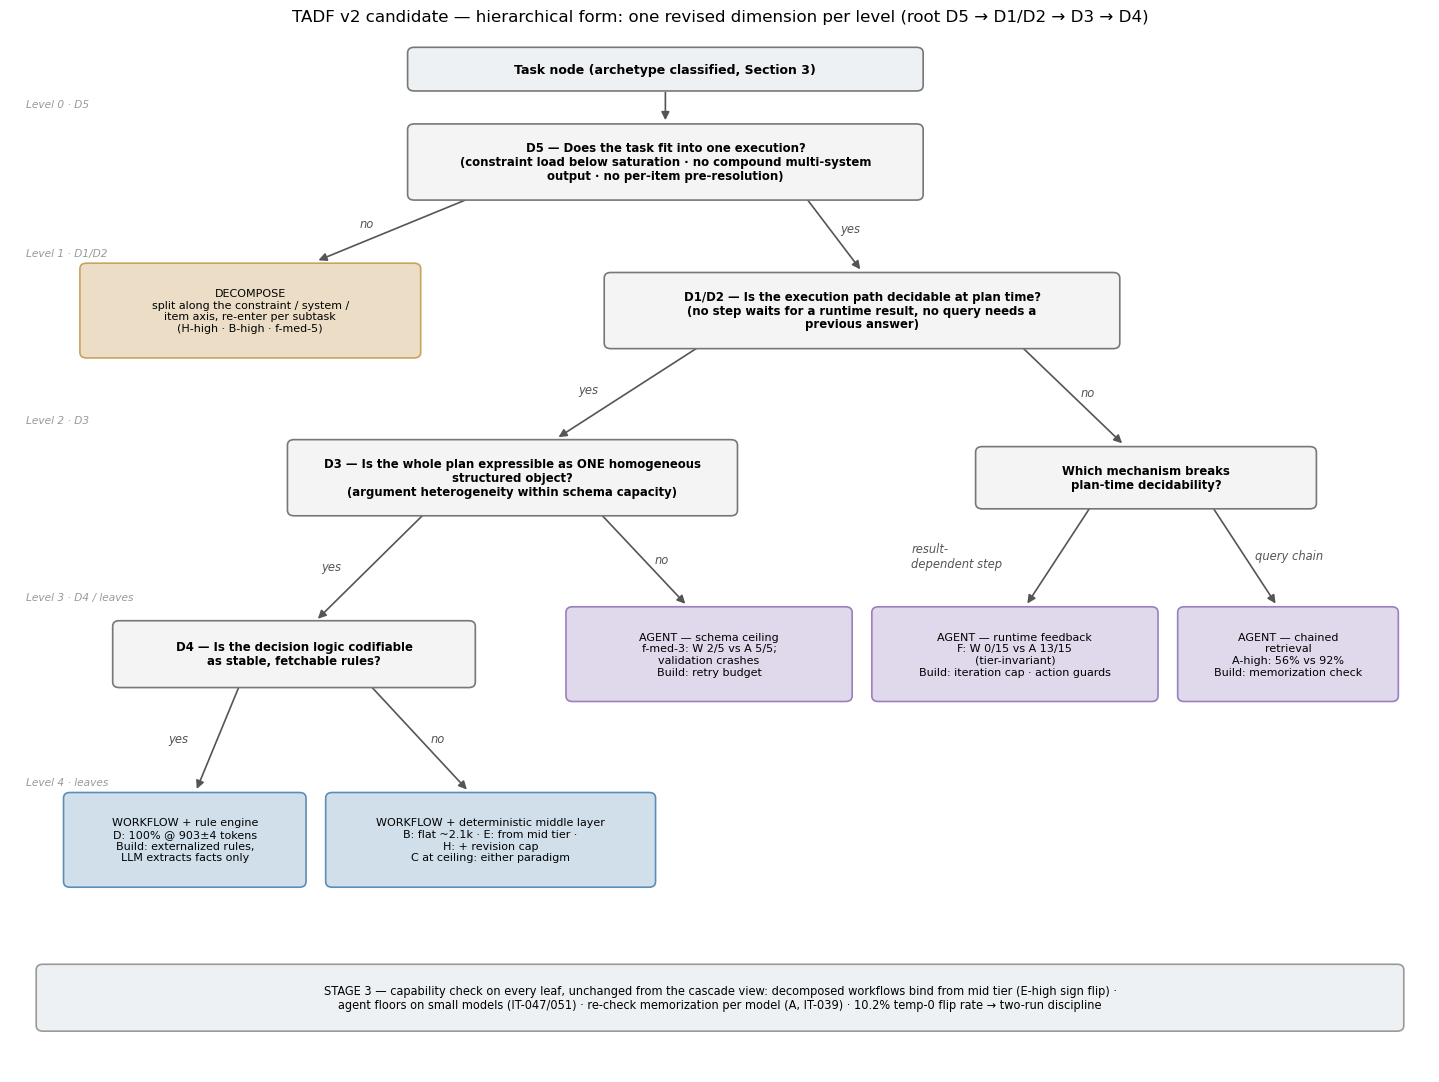

In [27]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

C_DC='#c9a25e'; C_GT='#f4f4f4'; C_EI='#eef1f3'
tintc=lambda c,a: (*plt.matplotlib.colors.to_rgb(c),a)
T_WF=tintc(C_WF,0.28); T_AG=tintc(C_AG,0.30)

def _tnode(ax,x,y,w,h,text,fc,ec='#777',fs=8.0,weight='normal'):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.6',
                                fc=fc,ec=ec,lw=1.2,zorder=2))
    ax.text(x,y,text,ha='center',va='center',fontsize=fs,zorder=3,fontweight=weight)

def _tedge(ax,x1,y1,x2,y2,label='',dx=1.0):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=12,
                                 color='#555',lw=1.2,zorder=1))
    if label: ax.text((x1+x2)/2+dx,(y1+y2)/2,label,fontsize=8.3,color='#555',
                      ha='left',va='center',fontstyle='italic')

f,ax=plt.subplots(figsize=(14.5,11))
ax.set_xlim(0,130); ax.set_ylim(0,112); ax.axis('off')

# root and level-0 gate (decomposability, D5)
_tnode(ax,60,108,46,3.5,'Task node (archetype classified, Section 3)',C_EI,fs=9,weight='bold')
_tnode(ax,60,98,46,7,'D5 — Does the task fit into one execution?\n(constraint load below saturation \u00b7 no compound multi-system\noutput \u00b7 no per-item pre-resolution)',C_GT,fs=8.4,weight='bold')
_tedge(ax,60,105.8,60,102.2)

# level 1: decompose leaf | plan-time decidability (D1/D2)
_tnode(ax,22,82,30,9,'DECOMPOSE\nsplit along the constraint / system /\nitem axis, re-enter per subtask\n(H-high \u00b7 B-high \u00b7 f-med-5)',tintc(C_DC,0.35),ec=C_DC)
_tnode(ax,78,82,46,7,'D1/D2 — Is the execution path decidable at plan time?\n(no step waits for a runtime result, no query needs a\nprevious answer)',C_GT,fs=8.4,weight='bold')
_tedge(ax,45,95.5,28,87.3,'no',dx=-4.5)
_tedge(ax,72,95.5,78,86.2,'yes')

# level 2 right: which mechanism breaks it  |  level 2 left: schema capacity (D3)
_tnode(ax,104,64,30,5.5,'Which mechanism breaks\nplan-time decidability?',C_GT,fs=8.4,weight='bold')
_tnode(ax,46,64,40,7,'D3 — Is the whole plan expressible as ONE homogeneous\nstructured object?\n(argument heterogeneity within schema capacity)',C_GT,fs=8.4,weight='bold')
_tedge(ax,92,78.8,102,67.5,'no')
_tedge(ax,64,78.8,50,68.2,'yes',dx=-5.0)

# level 3 agent leaves (from mechanism node)
_tnode(ax,92,45,25,9,'AGENT — runtime feedback\nF: W 0/15 vs A 13/15\n(tier-invariant)\nBuild: iteration cap \u00b7 action guards',T_AG,ec=C_AG)
_tnode(ax,117,45,19,9,'AGENT — chained\nretrieval\nA-high: 56% vs 92%\nBuild: memorization check',T_AG,ec=C_AG)
_tedge(ax,99,61.0,93,50.2,'result-\ndependent step',dx=-13.5)
_tedge(ax,110,61.0,116,50.2,'query chain')

# level 3: schema-ceiling agent leaf | codifiability gate (D4)
_tnode(ax,64,45,25,9,'AGENT — schema ceiling\nf-med-3: W 2/5 vs A 5/5;\nvalidation crashes\nBuild: retry budget',T_AG,ec=C_AG)
_tnode(ax,26,45,32,6,'D4 — Is the decision logic codifiable\nas stable, fetchable rules?',C_GT,fs=8.4,weight='bold')
_tedge(ax,54,60.2,62,50.2,'no')
_tedge(ax,38,60.2,28,48.6,'yes',dx=-4.5)

# level 4 workflow leaves
_tnode(ax,16,25,21,9,'WORKFLOW + rule engine\nD: 100% @ 903\u00b14 tokens\nBuild: externalized rules,\nLLM extracts facts only',T_WF,ec=C_WF)
_tnode(ax,44,25,29,9,'WORKFLOW + deterministic middle layer\nB: flat ~2.1k \u00b7 E: from mid tier \u00b7\nH: + revision cap\nC at ceiling: either paradigm',T_WF,ec=C_WF)
_tedge(ax,21,41.6,17,30.2,'yes',dx=-4.5)
_tedge(ax,33,41.6,42,30.2,'no')

# capability band
_tnode(ax,65,8,124,6,'STAGE 3 — capability check on every leaf, unchanged from the cascade view: decomposed workflows bind from mid tier (E-high sign flip) \u00b7\nagent floors on small models (IT-047/051) \u00b7 re-check memorization per model (A, IT-039) \u00b7 10.2% temp-0 flip rate \u2192 two-run discipline',C_EI,ec='#999',fs=8.2)

# level captions (dimension per level)
for y,txt in ((98,'Level 0 \u00b7 D5',), (82,'Level 1 \u00b7 D1/D2',), (64,'Level 2 \u00b7 D3',), (45,'Level 3 \u00b7 D4 / leaves',), (25,'Level 4 \u00b7 leaves',)):
    ax.text(1.5,y+6.2,txt[0] if isinstance(txt,tuple) else txt,fontsize=7.6,color='#999',ha='left',va='center',fontstyle='italic')

f.suptitle('TADF v2 candidate — hierarchical form: one revised dimension per level (root D5 \u2192 D1/D2 \u2192 D3 \u2192 D4)',fontsize=12)
plt.tight_layout(); plt.show()


### Findings — cascade (v1) vs hierarchy (v2 candidate)

- **What the tree asserts beyond the cascade:** mutual exclusivity of the branches, exactly one dimension per level, and a *subordination order* (D5 ⊐ D1/D2 ⊐ D3 ⊐ D4). The cascade only asserts "check in this order"; the tree asserts "these dimensions are hierarchically independent". The second claim is stronger and currently **unvalidated** — the grid tested each mechanism in near-isolation.
- **The one deliberate re-sort:** D3 (heterogeneous enumeration) moves to the plan-time-decidable side, because the bulk steps *are* known up front — the failure is schema capacity, not decidability. If the interaction tasks confirm this placement, the tree is the theoretically cleaner form (levels = Wood's dynamic → coordinative complexity); if instances surface where heterogeneity and runtime feedback interact non-additively, the cascade's flat priority order was the honest representation.
- **What Phase 2b must deliver for v2:** agenda item 9 (gate-interaction instances, e.g. rule application depending on a runtime read: D4×D1; chained search feeding heterogeneous bulk actions: D2×D3) validates the level ordering; item 8 (capability sweep) places Stage 3; items 1/6/7 sharpen the root and leaf definitions. Until then, v1 (cascade) is the citable framework; v2 is a labelled hypothesis.
- **Presentation note for the thesis:** the two views are complementary, not competing — cascade for the *architect's walkthrough* (Section 4), hierarchy for the *theoretical contribution* (dimension structure, Section 5 / Ch. 6). Both share one evidence base.


### 4.2 Process view — swimlane evaluation flow (architect's top level)

Third, complementary representation: the routing logic as a **process over dimension lanes**, the way an architect would actually run a top-level evaluation. Each lane is one evaluation theme; inside a lane the flow hits decisions (**hard exits**, solid border, evidence-backed) and picks up **recommendations** (dashed border) or **open items** (dashed, marked Phase 2b) on the way. Lane order is deliberate: *Task Boundary* first because reshaping the task is cheaper than any architecture choice; *Adaptivity* before *Planability* because its gate carries the strongest, capability-invariant evidence (G1); *Calibration* and *Preferences* are traversed by **every** path — they adjust and refine the outcome but never override the routing lanes. Making the open items visible inside the framework (dashed) is intentional: the artifact communicates its own evidence status (DSR: transparency of the design search, Hevner G6).

*What the next cell does:* it draws the swimlane flow in the house style — five lanes (Task Boundary & Scope → Adaptivity Requirements → Planability & Structure → Complexity & Capability Calibration → Preferences & Governance), main flow on the left spine, hard exits as coloured chips on the right, soft/open items dashed.


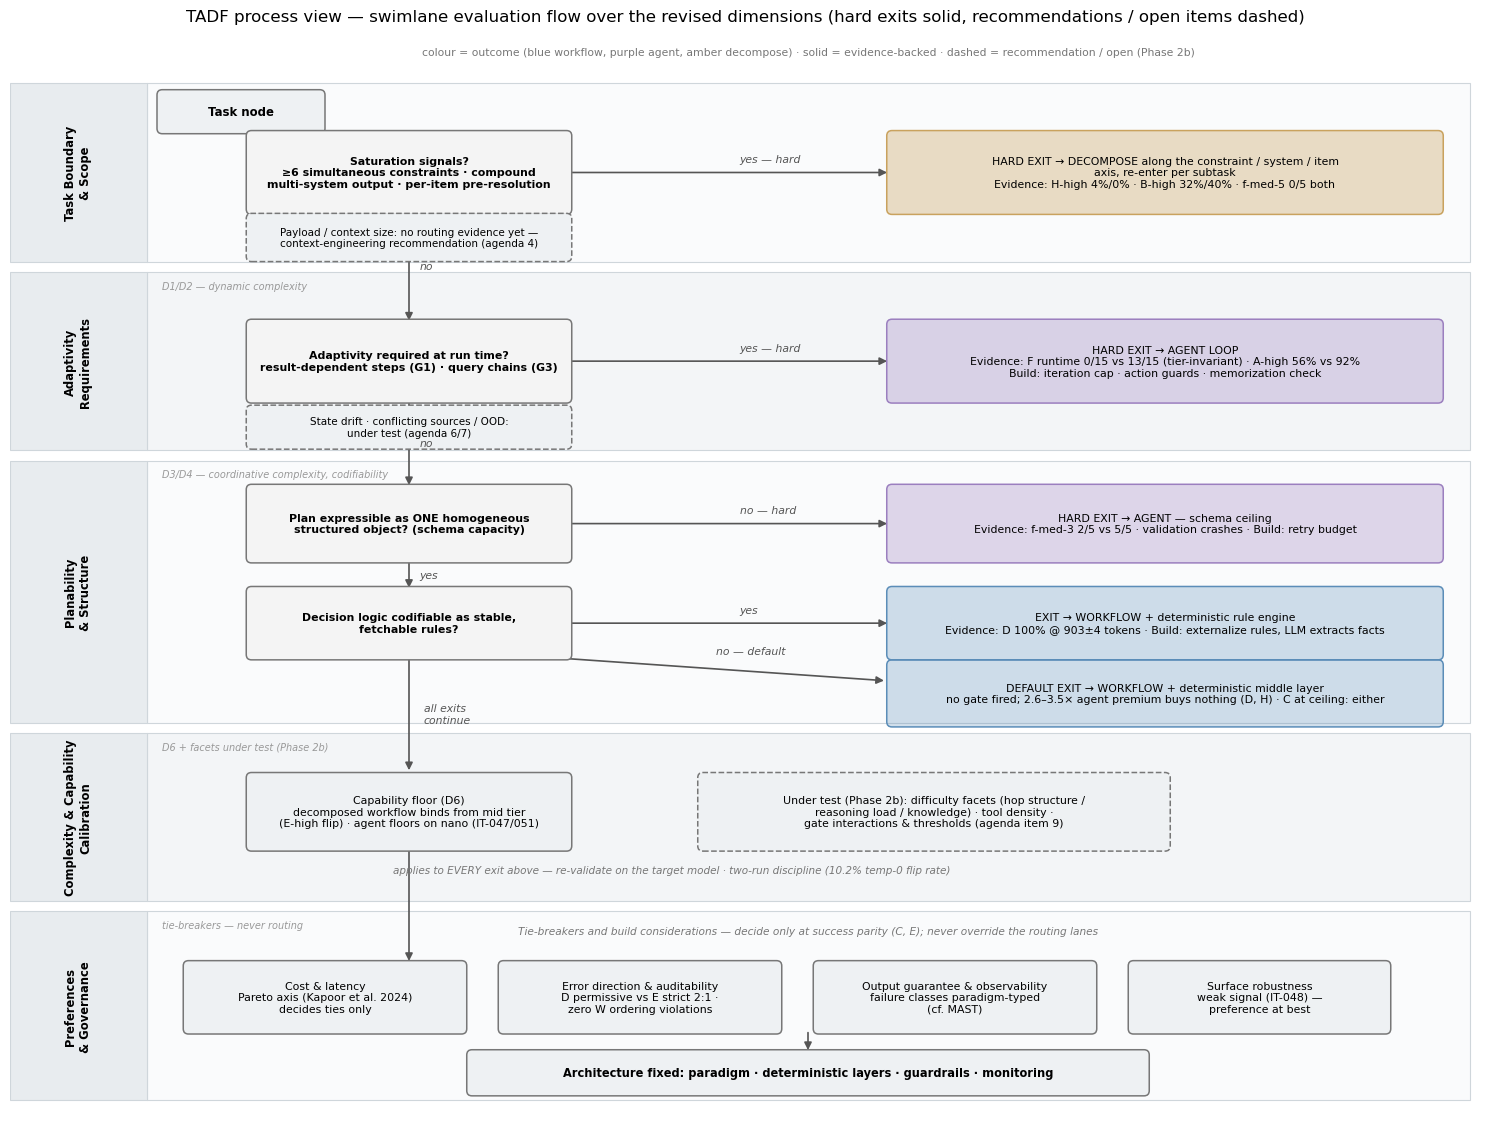

In [28]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

C_DC='#c9a25e'; C_GT='#f4f4f4'; C_EI='#eef1f3'
tintc=lambda c,a: (*plt.matplotlib.colors.to_rgb(c),a)
T_WF=tintc(C_WF,0.28); T_AG=tintc(C_AG,0.30)

def _snode(ax,x,y,w,h,text,fc,ec='#777',fs=7.9,weight='normal',dashed=False):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.5',fc=fc,ec=ec,
                                lw=1.1,zorder=3,linestyle='--' if dashed else '-'))
    ax.text(x,y,text,ha='center',va='center',fontsize=fs,zorder=4,fontweight=weight)

def _sarr(ax,x1,y1,x2,y2,label='',dx=1.0,dy=0.0):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=11,
                                 color='#555',lw=1.2,zorder=2))
    if label: ax.text((x1+x2)/2+dx,(y1+y2)/2+dy,label,fontsize=7.8,color='#555',
                      ha='left',va='center',fontstyle='italic')

f,ax=plt.subplots(figsize=(15,11.5))
ax.set_xlim(0,140); ax.set_ylim(0,104); ax.axis('off')

LANES=[('Task Boundary\n& Scope','D5 — decomposability',82,99,'#fafbfc'),
       ('Adaptivity\nRequirements','D1/D2 — dynamic complexity',64,81,'#f3f5f7'),
       ('Planability\n& Structure','D3/D4 — coordinative complexity, codifiability',38,63,'#fafbfc'),
       ('Complexity & Capability\nCalibration','D6 + facets under test (Phase 2b)',21,37,'#f3f5f7'),
       ('Preferences\n& Governance','tie-breakers — never routing',2,20,'#fafbfc')]
for name,tag,y0,y1,fc in LANES:
    ax.add_patch(Rectangle((13,y0),126,y1-y0,fc=fc,ec='#cfd6db',lw=0.8,zorder=0))
    ax.add_patch(Rectangle((0,y0),13,y1-y0,fc='#e8ecef',ec='#cfd6db',lw=0.8,zorder=0))
    ax.text(6.5,(y0+y1)/2,name,rotation=90,ha='center',va='center',fontsize=8.3,fontweight='bold')
    ax.text(14.5,y1-1.6,tag,fontsize=7.0,color='#999',ha='left',fontstyle='italic')

ax.text(76,101.7,'colour = outcome (blue workflow, purple agent, amber decompose) \u00b7 solid = evidence-backed \u00b7 dashed = recommendation / open (Phase 2b)',
        fontsize=7.8,color='#777',ha='center')

# ---- Lane 1: Task Boundary & Scope ----
_snode(ax,22,96.3,15,3.2,'Task node',C_EI,fs=8.4,weight='bold')
_snode(ax,38,90.5,30,7,'Saturation signals?\n\u22656 simultaneous constraints \u00b7 compound\nmulti-system output \u00b7 per-item pre-resolution',C_GT,weight='bold')
_snode(ax,110,90.5,52,7,'HARD EXIT \u2192 DECOMPOSE along the constraint / system / item\naxis, re-enter per subtask\nEvidence: H-high 4%/0% \u00b7 B-high 32%/40% \u00b7 f-med-5 0/5 both',tintc(C_DC,0.35),ec=C_DC)
_snode(ax,38,84.3,30,3.6,'Payload / context size: no routing evidence yet \u2014\ncontext-engineering recommendation (agenda 4)',C_EI,dashed=True,fs=7.5)
_sarr(ax,22,94.6,32,93.6); _sarr(ax,53.2,90.5,83.8,90.5,'yes \u2014 hard',dy=1.3)

# ---- Lane 2: Adaptivity ----
_snode(ax,38,72.5,30,7,'Adaptivity required at run time?\nresult-dependent steps (G1) \u00b7 query chains (G3)',C_GT,weight='bold')
_snode(ax,110,72.5,52,7,'HARD EXIT \u2192 AGENT LOOP\nEvidence: F runtime 0/15 vs 13/15 (tier-invariant) \u00b7 A-high 56% vs 92%\nBuild: iteration cap \u00b7 action guards \u00b7 memorization check',T_AG,ec=C_AG)
_snode(ax,38,66.2,30,3.2,'State drift \u00b7 conflicting sources / OOD:\nunder test (agenda 6/7)',C_EI,dashed=True,fs=7.5)
_sarr(ax,38,87,38,76.1,'no'); _sarr(ax,53.2,72.5,83.8,72.5,'yes \u2014 hard',dy=1.3)

# ---- Lane 3: Planability & Structure ----
_snode(ax,38,57,30,6.5,'Plan expressible as ONE homogeneous\nstructured object? (schema capacity)',C_GT,weight='bold')
_snode(ax,110,57,52,6.5,'HARD EXIT \u2192 AGENT \u2014 schema ceiling\nEvidence: f-med-3 2/5 vs 5/5 \u00b7 validation crashes \u00b7 Build: retry budget',T_AG,ec=C_AG)
_snode(ax,38,47.5,30,6,'Decision logic codifiable as stable,\nfetchable rules?',C_GT,weight='bold')
_snode(ax,110,47.5,52,6,'EXIT \u2192 WORKFLOW + deterministic rule engine\nEvidence: D 100% @ 903\u00b14 tokens \u00b7 Build: externalize rules, LLM extracts facts',T_WF,ec=C_WF)
_snode(ax,110,40.8,52,5.4,'DEFAULT EXIT \u2192 WORKFLOW + deterministic middle layer\nno gate fired; 2.6\u20133.5\u00d7 agent premium buys nothing (D, H) \u00b7 C at ceiling: either',T_WF,ec=C_WF)
_sarr(ax,38,69,38,60.4,'no'); _sarr(ax,53.2,57,83.8,57,'no \u2014 hard',dy=1.3)
_sarr(ax,38,53.6,38,50.6,'yes'); _sarr(ax,53.2,47.5,83.8,47.5,'yes',dy=1.3)
_sarr(ax,49,44.4,83.5,42.0,'no \u2014 default',dy=1.6)

# ---- Lane 4: Calibration (traversed by every path) ----
_snode(ax,38,29.5,30,6.5,'Capability floor (D6)\ndecomposed workflow binds from mid tier\n(E-high flip) \u00b7 agent floors on nano (IT-047/051)',C_EI)
_snode(ax,88,29.5,44,6.5,'Under test (Phase 2b): difficulty facets (hop structure /\nreasoning load / knowledge) \u00b7 tool density \u00b7\ngate interactions & thresholds (agenda item 9)',C_EI,dashed=True)
ax.text(63,23.7,'applies to EVERY exit above \u2014 re-validate on the target model \u00b7 two-run discipline (10.2% temp-0 flip rate)',
        fontsize=7.5,color='#777',ha='center',fontstyle='italic')
_sarr(ax,38,44.5,38,33.2,'all exits\ncontinue',dx=1.4)

# ---- Lane 5: Preferences & Governance ----
ax.text(76,17.8,'Tie-breakers and build considerations \u2014 decide only at success parity (C, E); never override the routing lanes',
        fontsize=7.6,color='#777',ha='center',fontstyle='italic')
_snode(ax,30,11.8,26,6,'Cost & latency\nPareto axis (Kapoor et al. 2024)\ndecides ties only',C_EI)
_snode(ax,60,11.8,26,6,'Error direction & auditability\nD permissive vs E strict 2:1 \u00b7\nzero W ordering violations',C_EI)
_snode(ax,90,11.8,26,6,'Output guarantee & observability\nfailure classes paradigm-typed\n(cf. MAST)',C_EI)
_snode(ax,119,11.8,24,6,'Surface robustness\nweak signal (IT-048) \u2014\npreference at best',C_EI)
_snode(ax,76,4.6,64,3.4,'Architecture fixed: paradigm \u00b7 deterministic layers \u00b7 guardrails \u00b7 monitoring',C_EI,fs=8.2,weight='bold')
_sarr(ax,38,26.2,38,15.0); _sarr(ax,76,8.7,76,6.5)

f.suptitle('TADF process view \u2014 swimlane evaluation flow over the revised dimensions (hard exits solid, recommendations / open items dashed)',fontsize=12)
plt.tight_layout(); plt.show()


### Findings — three representations, one evidence base

- **Division of labour:** the cascade (Section 4) is the *walkthrough* (priority order = evidence ranking, first match wins); the hierarchy (4.1) is the *theoretical claim* (one dimension per level, subordination testable via agenda item 9); the swimlane (4.2) is the *top-level process* — it tells an architect which **themes** to evaluate in which order, and it is the only view that distinguishes hard exits from recommendations and open items.
- **Hard vs soft inside one lane:** in *Task Boundary & Scope*, constraint load / compound output / per-item resolution are hard (saturation evidence), while payload/context size is deliberately dashed — no routing evidence yet (agenda 4). The same task property can thus sit in the framework today as a recommendation and be promoted to a gate by Phase 2b — the swimlane makes that promotion path explicit.
- **What was added beyond the sketch:** a *Calibration* lane (capability floor D6 plus the Phase-2b facets) traversed by every path — without it the framework silently assumes mid-tier capability; and a closing step (architecture = paradigm + deterministic layers + guardrails + monitoring), because the grid shows the build notes are part of the routing outcome, not an afterthought.
- **Open:** whether *Preferences & Governance* stays a lane or becomes the Phase-3 APS weighting layer (practitioner input) should be decided after the interviews — the swimlane is the natural place where APS weights would plug in.


### 4.3 Decision-table form — the evaluation as a category checklist

Fourth representation: the full evaluation as one **decision table**, grouped into seven categories in evaluation order. Read each question with its specification and take the decision in the answer columns: <span style="color:#c0392b;font-weight:bold">red = hard break</span> — routing is fixed, stop evaluating the routing categories; normal = the better choice or a recommendation *given the decisions taken so far*; <span style="color:#8a6d1a;font-style:italic">amber italic = first guideline with placeholders</span> — numbers and routing to be calibrated by the Phase 2b tests. Categories 4–7 are always evaluated, whatever was routed above. One gap is kept out of the table deliberately: a **hybrid** leaf (workflow with an embedded agentic resolution step) is suggested by the G failure census — the workflow's deficit there is a resolution *subtask*, not planning — but is untested; it enters via the Phase 4 case study, not via this table.

<table style="border-collapse:collapse;width:100%">
<tr><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">#</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Category</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Question</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Specification — when it applies</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Yes &rarr;</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">No &rarr;</th></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">1.1</td><td rowspan="2" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">1 — Task Boundary<br>&amp; Requirements<br><span style="font-weight:normal;font-size:11px">(D5; size, constraints, scope)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the task fit into <b>one</b> execution?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">It does <i>not</i> fit if any of: &ge;6 simultaneous output constraints; one answer combining 3+ fields across systems; every item needs individual pre-resolution before acting. <i>Evidence: H-high 4%/0% &middot; B-high 32%/40% &middot; f-med-5 0/5 both.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">DECOMPOSE — hard break.</span> Split along the constraint / system / item axis, re-enter the table per subtask.</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">1.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the input / payload within normal context sizes?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">First guideline — placeholders, to be calibrated in Phase 2b (agenda 4); model capability shifts these numbers:</span> input context up to &asymp;[c<sub>1</sub>] tokens &rarr; no task splitting needed. LLM-Workflows: batch inputs at &asymp;[b<sub>1</sub>] input tokens per LLM call (deterministic chunking). Agents: reliable loop context from &asymp;[a<sub>1</sub>] to &asymp;[a<sub>2</sub>] tokens — beyond that, try batching / compaction before splitting the task.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Recommendation, not a routing gate: chunk/batch (workflow) or compact (agent); only split the task if that fails. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.1</td><td rowspan="3" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">2 — Adaptability<br><span style="font-weight:normal;font-size:11px">(D1/D2; dynamic complexity)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does any step depend on a <b>runtime-observed result</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">The next action can only be chosen after seeing a tool result — including a single if&ndash;then branch on data that must first be read. <i>Evidence: F runtime W 0/15 vs A 13/15 (tier-invariant); f-med-2 1/5 vs 5/5.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Must retrieval build on its own <b>intermediate answers</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Query <i>n</i> can only be phrased once answer <i>n&minus;1</i> is known (multi-hop chains). <i>Evidence: A-high W 56% vs A 92%.</i> Exception: simple lookups <b>and</b> low error consequence &rarr; LLM-Workflow viable and cheaper (IT-012).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break</span> (unless the exception applies &rarr; LLM-Workflow).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Can the environment <b>state change mid-run</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test (agenda 6):</span> state drift — a case closes or a slot fills while the task runs; our grid environments were statically seeded, so this cell carries no evidence yet.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test — routing will be derived from the Phase 2b results (family M, Moving Target).</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.1</td><td rowspan="5" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">3 — Planability<br>of the Task<br><span style="font-weight:normal;font-size:11px">(D3/D4; coordinative complexity, codifiability; rows 3.3&ndash;3.4 under test)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the whole plan expressible as <b>one homogeneous structured object</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Fails when a bulk action carries heterogeneous per-item arguments (own values, owners, notes); identical bulk is fine regardless of count. <i>Evidence: f-med-3 W 2/5 vs A 5/5; f-med-4 5/5 both; validation crashes.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span></td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the task <b>fully plannable</b>, incl. decision logic as stable, fetchable rules?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Steps, tools and arguments known up front; rules complete and stable, retrievable at run time (policy handbook, thresholds, escalation matrix). <i>Evidence: D 100% @ 903&plusmn;4 tokens vs agent 80% @ 6&times;.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-WORKFLOW + deterministic rule engine — better choice.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Steps and tools known, but the <b>number of calls</b> unknown?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test (agenda 2a):</span> iterate-until patterns; the grid contains no cell that isolates this property.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test — routing will be derived from the Phase 2b results (family P, Plan Uncertainty).</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.4</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Number of calls known, but <b>which tool / step</b> unknown?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test (agenda 2b):</span> tool-selection uncertainty at plan time; not isolated by any grid cell.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Under test — routing will be derived from the Phase 2b results (family P, Plan Uncertainty).</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.5</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">None of the above fired?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Plannable task without special structure requirements. <i>Evidence: without a fired gate the 2.6&ndash;3.5&times; agent premium buys nothing (D, H); single-pass tasks at ceiling (C): either paradigm.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-WORKFLOW + deterministic middle layer — default.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">&mdash;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.1</td><td rowspan="4" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">4 — Errors, Auditability<br>&amp; Robustness<br><span style="font-weight:normal;font-size:11px">(always evaluate)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Must errors be near-zero and every decision <b>audit-ready</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Workflow + deterministic engine on a strong model is near error-free and per-node auditable (D: 100% @ 903&plusmn;4; zero ordering violations in G; fixed graph = replayable trace). Agent loops are harder to audit and their errors skew permissive (12/15 under-escalations in D).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Prefer LLM-Workflow wherever rows 1&ndash;3 allow; add a deterministic validation layer regardless of paradigm.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Keep routing; log traces anyway. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is <b>under-blocking</b> the dangerous error direction?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Error directions are paradigm-typed: agent compliance errors are permissive (under-escalation, 80% in the dangerous direction); workflow verification errors are strict 2:1 (false fails). <i>Evidence: D error census; E strict-bias census.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Deterministic decision layer mandatory (rule engine / verdict engine); do not leave the final decision inside a loop.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Calibrate strictness; use dual scoring (judge + deterministic). continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the consumer require a <b>schema-guaranteed output</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Downstream systems consume typed objects. The workflow enforces the schema by construction (structured output at every node); the agent needs post-validation. <i>Evidence: C was routed on the structured-output guarantee, not on cost (0.8&times; inverted ratio).</i> Caveat: schema complexity has its own ceiling (row 3.1).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-Workflow at parity; if Agent was routed above, add deterministic schema post-validation.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.4</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the incoming input <b>clean and well-formed</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Weakest criterion in this category — evaluate last. Surface noise (typos, jargon, casual phrasing) barely discriminates (IT-048: both paradigms largely robust). On messy structured input the agent was slightly more robust (B robustness A 15/15 vs W 13/15, IT-036); the workflow is more accurate on clean input.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">No action; keep routing. continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">First choice: add an input-normalization step regardless of paradigm; only at persistent parity let messiness tip toward Agent. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">5.1</td><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">5 — Cost &amp; Latency<br><span style="font-weight:normal;font-size:11px">(always evaluate; Pareto axis, Kapoor et al. 2024)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is cost or latency a <b>binding constraint</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A well-built workflow is 2.6&ndash;3.5&times; cheaper per run (up to 6&ndash;8&times; per solved task in B/D), difficulty-invariant in cost (B &asymp;2.1k flat; D 903&plusmn;4), and faster wherever the agent loops (B, F, G). The agent premium is justified <b>only</b> where a red gate fired above (A-high, F, G) — there it buys success, not comfort.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">At success parity choose LLM-Workflow; question every Agent decision that has no fired gate behind it.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decide on the remaining preferences. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">6.1</td><td rowspan="2" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">6 — Flexibility<br><span style="font-weight:normal;font-size:11px">(build-time trade-off)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Do you need to <b>start flexible</b> — input distribution not yet operationalizable?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A workflow binds you to an operationalized input distribution: one compiled graph then answers every same-type request (B 15/15) — but only within scope; out-of-scope inputs as the agent's fallback domain is <span style="color:#8a6d1a;font-style:italic">still unbacked (agenda 7)</span>. Building a workflow requires up front: output schemas, a deterministic middle layer, input operationalization. Agents start flexible but need their guardrails from day one.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Start as guarded Agent, harden into a Workflow once the input distribution stabilizes (hybrid migration path).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Build the Workflow directly. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">6.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">How stable is the <b>task definition</b> itself?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A workflow binds build effort to a stable task shape (one compiled graph then serves every same-type request, B 15/15); if the process definition changes frequently, rebuild cost recurs, while an agent absorbs definition changes via prompt/runbook. <span style="color:#8a6d1a;font-style:italic">Not testable in Phase 2b (longitudinal) — routed to the Phase 3 practitioner interviews as a maintainability/APS question.</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Stable &rarr; the workflow investment amortizes (build once, run cheap).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Volatile &rarr; guarded Agent or late-binding workflow parts; revisit after stabilization. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.1</td><td rowspan="3" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">7 — Next Steps<br><span style="font-weight:normal;font-size:11px">(model &amp; architecture build-up — teaser; details in the build-notes discussion below)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the target model clear the <b>capability floor</b> of the chosen configuration?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decomposed-judgment workflows bind only from mid tier (E-high sign flip); agent recovery and runbook argument-binding fail on small models (IT-047/051); retrieval tasks need the per-model memorization re-check (IT-039); two-run discipline (10.2% temp-0 flip rate).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Proceed to build.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Adjust, do not re-route: raise the model tier or simplify the structure, then re-check.</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decided <b>LLM-Workflow</b> — what to build?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Lessons from the grid (teaser): externalized rules/specs; deterministic executor / verdict engine / compliance checks as validation bottlenecks; schema-complexity budget for plan objects; revision caps; chunking as context parameter; canonical-minimal graph, LLM confined to semantic roles.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px" colspan="2">&rarr; Workflow build checklist (to be detailed in the discussion text).</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decided <b>Agent</b> — what to build?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Lessons from the grid (teaser): iteration/recursion caps; prohibited-action guards; token-budget alarms; retry budgets; context compaction; per-model memorization checks; deterministic post-state validation of outcomes.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px" colspan="2">&rarr; Agent build checklist (to be detailed in the discussion text).</td></tr>
</table>

<small><span style="color:#c0392b;font-weight:bold">red = hard break</span> (routing fixed) &middot; normal = better choice / recommendation given prior decisions &middot; <span style="color:#8a6d1a;font-style:italic">amber italic = first guideline / placeholder, calibrated by Phase 2b</span> &middot; categories 4&ndash;7 always evaluated. Same evidence base as Sections 4&ndash;4.2.</small>


## 5. Task dimension revision for routing

The four a-priori dimensions (thesis Section 4.2.4: Step Predictability, Information Availability, Output Ambiguity, Error Consequence) organized the archetype space, but the grid shows they bind at a finer granularity: the routing-active properties are **sub-dimensional mechanisms**. This section consolidates the revision — which dimensions discriminate between the paradigms, which only express preferences, and which do not discriminate at all — and derives the follow-up task designs (Phase 2b candidates). This *refines* the a-priori taxonomy rather than refuting it (DSR: design as a search process, Hevner G6); the taxonomy keeps its role as archetype classifier, while routing attaches to the mechanisms below.

### Discriminating dimensions (decide the paradigm)

| # | Dimension (mechanism) | Gate | Grid evidence | Literature anchor |
|---|---|---|---|---|
| D1 | Runtime-result dependence of the transition | G1 | F runtime 0/15 vs 13/15, tier-invariant; one read-conditional branch: 1/5 vs 5/5 | Wood 1986: *dynamic* complexity; sharpens the "flowchart test" (Schluntz & Zhang 2024) |
| D2 | Retrieval-path adaptivity (query *n* needs answer *n−1*) | G3 | A-high 56% vs 92%; gap shrinks with capability, never flips | Adaptive-RAG (Jeong et al. 2024); BrowseComp |
| D3 | Argument/schema heterogeneity of the plan object | G4 | f-med-3 2/5 vs 5/5; f-med-4 (16 identical) 5/5 both; ActionPlan validation crashes | Tam et al. 2024 (format-restriction degradation); Wood 1986: *coordinative* complexity |
| D4 | Codifiability of the decision logic | G2 | D: 100% @ 903±4 tok vs 80% @ 6×; robustness 18/18 vs 13/18 | Kim et al. 2026: validation bottleneck |
| D5 | Constraint load / decomposability | S0 | H-high 1/25 & 0/25; B-high 8/25 vs 10/25; f-med-5 0/5 both | Kim et al. 2026: decomposability; IFScale (2025): constraint-count degradation |
| D6 | Model capability floor (interaction term, not a task property) | Stage 3 | E-high sign flip (only one in the grid); nano floors IT-047/051 | Kim et al. 2026: capability ceiling |

### Preference dimensions (decide at success parity)

- **Token cost & latency** — a Pareto axis, not a router (Kapoor et al. 2024: accuracy-optimal agents cost 4.4–10.8× more than Pareto-efficient ones); decisive only where success ties (C, E).
- **Error direction & auditability** — D agent errors 12/15 permissive vs E workflow 2:1 strict; zero workflow ordering violations in G. *Error Consequence is hereby reframed from router to moderator*; its weighting is located in the Phase 3 practitioner APS interviews, not in Phase 2 experiments.
- **Structured-output guarantee & observability** — failure classes are paradigm-typed (Section 3-G census; cf. the MAST failure taxonomy, Cemri et al. 2025).
- **Robustness to surface variance** — IT-048: both paradigms largely robust; weak signal, preference at best.

### Non-discriminating (per this grid)

Linguistic complexity and request ambiguity (C at ceiling; the robustness suite *is* the controlled surface-form manipulation — semantics constant, form varied — and answered this facet negatively, IT-048); information availability per se (D rebuilt to fetch rules at runtime, IT-041, and still 100%); step/item **count** per se (f-med-4; D rule-count-invariant); **difficulty as a scalar** — non-monotonic tokens in A (med > high), D difficulty-invariant, E flips on capability rather than difficulty. The scalar finding is the direct structural challenge to difficulty-only routing (Su et al. 2025 DAAO; Gao et al. 2025) and is pre-registered for the Condition-3-vs-4 router comparison.


### Completeness check against task-complexity theory (Liu & Li 2012)

Liu & Li (2012) consolidate the task-complexity literature into ten dimensions. The mapping below shows that with two justified exclusions, every dimension is either tested, scheduled in the agenda, or explicitly excluded — the completeness argument for thesis Section 4.2. The classic Wood (1986) triple maps directly: *component* complexity does not discriminate, *coordinative* complexity discriminates via D3/D2, *dynamic* complexity via D1 — the revision connects to established IS theory, not only to the LLM literature.

| Liu & Li dimension | Status | Where |
|---|---|---|
| Size (number of elements) | tested — does **not** discriminate per se; binds only as constraint load | f-med-4; D rule-count invariance; S0 |
| Variety (heterogeneity) | tested — discriminates | G4 / D3 |
| Relationship (interdependence) | tested — discriminates | G1, G3 / D1, D2 |
| Ambiguity (goal/request clarity) | tested — does not discriminate | C at ceiling; A open output schema |
| Variability (change *during* execution) | **gap** → agenda item 6 | environments statically seeded; G1 covers reaction to own actions, not external state change |
| Unreliability (wrong/conflicting info) | partial → agenda item 7 | surface perturbations + D distractor policies tested; conflicting sources untested |
| Novelty (unexpected/OOD inputs) | **gap** → agenda item 7 | thesis 6.1 note claims OOD is "the agent's fallback domain" — currently unbacked |
| Incongruity (format mismatch) | partial → folded into agenda item 4 | payload realism IT-016; robustness suite |
| Action complexity | tested | archetype F |
| Temporal demand (time pressure) | excluded, justified | constant across paradigms; latency is an outcome metric here, not a task property |

**Dimensions considered and not adopted.** *Partial observability* (Kim et al. 2026) is a multi-agent coordination regime — which agent sees which sub-state; at |A| = 1 (both paradigms are single-locus, thesis formal note) it collapses into D1/D2 and cannot be measured separately in this design. *Error consequence as an experimental moderator*: its moderator role is already evidenced (error directions in D/E; the error-consequence-conditioned exception in A, IT-012); varying *declared* stakes does not change model behavior, and its weighting belongs to Phase 3 (APS).


### Research agenda — Phase 2b task designs

1. **Decomposition axes** (D5; Kim et al. 2026). One task family per saturation cell, decomposing the same task along exactly one axis: *constraint splitting* (H-type: 2×3 instead of 6 simultaneous constraints, pipelined), *system splitting* (B-type: per-system subqueries + deterministic merge), *item splitting* (F-type: resolve→act per item). Compare decomposed-workflow vs decomposed-agent vs both monolithic. Question: is saturation removable, and which paradigm carries the *pieces*? Additionally measure the latency gain of deterministic parallel DAG fan-out over sequential agent loops on the parallelizable splits (cf. Kim et al. 2026).
2. **Planability axes** (D1/D3 separation). Four sub-conditions on an otherwise identical task: (a) step *count* unknown, step type known (iterate-until); (b) *which tool* unknown (tool-selection uncertainty); (c) *arguments* unknown (binding uncertainty); (d) *ordering* unknown. Grid-derived hypothesis: only (c) and result-dependent (a) flip the paradigm.
3. **Difficulty facets, narrowed** (scalar-difficulty test). Instance pairs varying exactly one facet at constant others: hop/relation structure vs reasoning load vs required knowledge (memorization-controlled, IT-039). Linguistic complexity is *excluded with evidence* (robustness suite, IT-048); request ambiguity likewise (C). Doubles as the stress test for the DAAO-style router (Condition 3).
4. **Context management** (incl. Liu & Li *incongruity*). Same task at payload ×1/×5/×20, with/without compaction; workflow chunking vs agent context re-entry. Question: routing dimension or implementation parameter? (Context-rot literature; Anthropic context engineering; Lost in the Middle.)
5. **Tool density** (Kim et al. 2026, adopted). Vary the number of available irrelevant tools. Hypothesis: agent degrades with tool count, workflow invariant (tools pre-bound); D distractor policies (IT-045) point this way.
6. **State drift / variability** (Liu & Li gap). Same F/G task, but the seeded state changes deterministically mid-run (a case closes, a calendar slot fills). Hypothesis: shifts tasks from G2/default into G1.
7. **Conflicting sources & OOD inputs** (Liu & Li unreliability + novelty). A/B instances with contradicting sources; requests just outside the operationalized input distribution. Directly tests the currently unbacked "agent fallback domain" claim (thesis 6.1 note).
8. **Capability-floor sweep per gate** (D6). One task family per gate across model tiers to turn Stage 3 from qualitative into quantified thresholds.
9. **Gate interactions & hierarchy validation** (tree form, Section 4.1). Factorial instance pairs where two gates fire at once — rule application depending on a runtime read (D4×D1), chained search feeding heterogeneous bulk actions (D2×D3), codifiable rules emitting heterogeneous output objects (D4×D3) — plus near-threshold instances to place the split points. Question: does the first-match cascade order hold, are hybrids the right leaf for mixed cells, and is the hierarchical subordination D5 ⊐ D1/D2 ⊐ D3 ⊐ D4 justified?
10. **User-interaction tasks** (τ-bench pattern, Yao et al. 2024). Scripted mid-task user turns (clarification requests, approvals) reusing the H scripted-feedback machinery — symmetric for both paradigms. Question: does required mid-task interaction route to Agent, or do workflow interrupt points suffice? Doubles as a pass^k-style multi-trial reliability measurement, extending the two-run discipline.

### Sources

Schluntz & Zhang 2024, [Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents) (Anthropic) · Kim et al. 2026, [Towards a Science of Scaling Agent Systems](https://arxiv.org/abs/2512.08296) (arXiv:2512.08296) · Su et al. 2025, DAAO (thesis Section 2) · Gao et al. 2025, [Single-agent or Multi-agent Systems? Why Not Both?](https://arxiv.org/abs/2505.18286) (arXiv:2505.18286) · Jeong et al. 2024, [Adaptive-RAG](https://aclanthology.org/2024.naacl-long.389/) (NAACL 2024) · Tam et al. 2024, [Let Me Speak Freely?](https://arxiv.org/abs/2408.02442) (EMNLP Industry) · Huang et al. 2024 (ICLR) / Kamoi et al. 2024, [self-correction survey](https://arxiv.org/abs/2406.01297) (TACL) · [IFScale: How Many Instructions Can LLMs Follow at Once?](https://arxiv.org/abs/2507.11538) (2025) · Kapoor et al. 2024, [AI Agents That Matter](https://arxiv.org/abs/2407.01502) · Cemri et al. 2025, [Why Do Multi-Agent LLM Systems Fail?](https://arxiv.org/abs/2503.13657) (MAST) · Wood 1986, Task complexity: definition of the construct (OBHDP 37) · Liu & Li 2012, [Task complexity: A review and conceptualization framework](https://www.sciencedirect.com/science/article/abs/pii/S0169814112000868) (IJIE 42) · Yao et al. 2023 (ReAct) · Sumers et al. 2024 (CoALA)


### Phase 2b build decision — four task families (based on the Phase 2a findings)

From the ten agenda items above, **four task families** are built and swept; they are the items that resolve the framework's open (amber) cells, and they stay inside the operationalized task space of this thesis (SME CRM environment: accounts / cases / opportunities, mail / calendar / policy-store tools). Naming follows the archetype convention:

| Family | Name | Design (variants) | Resolves in the framework | Agenda item |
|---|---|---|---|---|
| **P** | Plan Uncertainty ("Planungslücken") | Data-hygiene job in 4 variants: (P-a) call count unknown but derivable from one read · (P-b) call count result-dependent (escalate until condition) · (P-c) which tool unknown (data may live in cases, opportunities, or mail) · (P-d) order discoverable only at run time | Table rows 3.3 / 3.4; sharpens the D1–D3 boundary | 2 |
| **X** | Crossed Gates ("Gekreuzte Gates") | Two mechanisms fire at once: (X-1) rule-based decision where the applicable policy version depends on a runtime read (D4×D1) · (X-2) chained research feeding heterogeneous per-target updates (D2×D3) · (X-3) rule decision emitting heterogeneous action objects (D4×D3) | Cascade first-match order; v1-vs-v2 (hierarchy) decision of Section 4.1 | 9 |
| **L** | Payload Scaling ("Lastprobe") | Identical B/F tasks at input ×1 / ×5 / ×20 (more records, longer histories; same task content) | The placeholder numbers in row 1.2 ([c₁], [b₁], [a₁], [a₂]) | 4 |
| **M** | Moving Target ("Bewegliches Ziel") | F/G tasks where the seeded state changes deterministically after call *n* (a case closes, a slot fills) — both paradigms see the identical change | Table row 2.3 | 6 |

**Input-neutrality rules (design law, from IT-049/IT-051).** Every instruction is phrased as a natural colleague request; identical text and identical shared runbook/policy excerpt for both paradigms; no procedural hints, tool names, step counts, or format directives a real requester would not type. Difficulty lives exclusively in the task *shape* (seed data, state), never in the phrasing. Pre-sweep check per instance: "would a normal requester write this?"; memorization check wherever retrieval is involved. Scoring stays outcome-centric (post-state predicates) — paradigm-agnostic.

**DSR note — no routing hypotheses attached to the artifact.** The TADF is the design artifact of this work; its open cells therefore carry *no* pre-committed routing direction (rows 2.3/3.3/3.4 state only "under test"). What is fixed in advance is the *decision rule* — how results translate into a table entry (e.g., a variant routes to Agent if the workflow–agent gap exceeds the two-run noise band across tiers) — not the direction. Routing is decided from the results.

**Execution.** Same discipline as the Phase 2a grid: three-tier capability grid (nano 2× clean, mini 2× clean, gpt-5.2 1×, judge frozen, temperature 0, seed 42), results under `data/results/phase2b/`, analysis in a dedicated notebook (`results_analysis_phase2b.ipynb`) with the same findings-under-every-output discipline. Each family gets its own iteration-log entry at build time (IT-056 ff., one per family). Side benefit: the P/X/L/M instances are unseen data and double as a free out-of-sample check of the v1 gates.

**Deferred (explicitly, with consequence):** decomposition axes (1), difficulty facets (3), tool density (5), conflicting sources / OOD (7 — the thesis 6.1 "agent fallback domain" note must be softened accordingly), user interaction (10) → future work. The capability-floor sweep (8) is folded in: all four families run on the full three-tier grid. Framework-application reliability and out-of-sample performance are covered by the thesis evaluation phases themselves (Phase 3 practitioner interviews incl. inter-rater routing exercise; Phase 4 case study).


### Memo für die Ausarbeitung (Kap. 4.2 / 4.5 / 6) — beim Schreiben erinnern

- **Framing:** Die Dimension-Revision als DSR-Ergebnis erster Klasse verkaufen (Hevner G6, design as search) — 4.2.4 wird *verfeinert, nicht widerlegt*. Die Taxonomie bleibt Klassifikator der Archetypen; das Routing hängt an den Sub-Mechanismen D1–D5. Nicht defensiv schreiben.
- **IS-Verankerung zuerst:** Wood (1986) component/coordinative/dynamic → nicht-diskriminierend / D3–D2 / D1, dann Liu-&-Li-Vollständigkeitstabelle. Das Argument lautet: der Befund schließt an etablierte Task-Complexity-Theorie an, die LLM-Literatur liefert nur die Mechanismen.
- **DAAO/Gao-Abgrenzung vorsichtig timen:** "Skalar-Schwierigkeit misroutet D-high und F-low" ist bis zur Condition-3-Auswertung eine *vorregistrierte Hypothese* — im Text als solche kennzeichnen, erst nach der Router-Analyse als Befund formulieren.
- **Kim et al. (2026) dreifach nutzen:** Validation Bottleneck (übernommen, task-level bestätigt), Decomposability (zum dritten Routing-Outcome erweitert), Partial Observability (begründet nicht übernommen: |A| = 1). Tool Density als übernommene offene Dimension nennen.
- **Eigenständiger Beitragskandidat für Kap. 6:** Die drei Sättigungszellen indizieren drei *Dekompositionsachsen* (Constraint- / System- / Item-Splitting) — als Design-Theory-Nugget ausarbeiten, nicht nur als Limitation.
- **Negativbefunde als Evidenz berichten:** sprachliche Komplexität (IT-048, Robustness-Suite als kontrollierte Manipulation), Info Availability per se (IT-041, D-Umbau). Explizit als belegte Ausschlüsse schreiben, nicht weglassen.
- **Flag vor Abgabe:** Die 6.1-Behauptung "out-of-scope inputs are the agent's fallback domain" ist unbelegt → Agenda-Item 7 durchführen oder Formulierung abschwächen.
- **Offener Widerspruch auflösen:** G-Kostenprämie im Grid steigend (2.0→3.4× per-run) vs. frühere Lesart fallend (3.9→1.4× per-solved) — vor jedem Zitat in 4.5 per tokens-per-solved-task nachrechnen (Findings G).
- **Methodenbeitrag hervorheben (4.4):** Memorisierung als Konfundierung, nicht als Schwierigkeitsfacette — per-Modell-No-Tool-Check als übertragbare Methode (IT-031/039); ebenso die Zwei-Run-Disziplin (10.2% Flip-Rate) als Messvorschrift.
- **Error Consequence als Brücke schreiben:** 4.5 (Moderator, Fehlerrichtung D/E, Ausnahme A-low) → 5.1 (APS-Gewichtung durch Praktiker). Der rote Faden Phase 2 → Phase 3 läuft über genau diese Dimension.
- **Limitations konsistent wiederholen:** n = 5–25 pro Zelle, 10.2% Temp-0-Flip-Rate, eine Modellfamilie (GPT-5.x), synthetische Latenz (D-022), C als degenerierter Vergleich — bei jeder Zahl im Fließtext mitdenken.
